In [1]:
import numpy as np

# -----------------------------------------------------------
# 1. Align probability dictionaries (handles missing states)
# -----------------------------------------------------------
def align_distributions(sim_probs, hw_probs, normalize=True):
    """
    Takes two probability dictionaries with possibly different sets of states.
    Returns aligned probability arrays P and Q.

    Example input:
        sim_probs = {"000":0.5, "001":0.5}
        hw_probs  = {"000":0.6, "010":0.4}

    Output:
        P, Q aligned as [000,001,010]
        P = [0.5, 0.5, 0.0]
        Q = [0.6, 0.0, 0.4]
    """

    # All states appearing in either dictionary
    all_states = sorted(set(sim_probs.keys()) | set(hw_probs.keys()))

    # Convert dict → aligned numpy arrays
    P = np.array([sim_probs.get(s, 0.0) for s in all_states], dtype=float)
    Q = np.array([hw_probs.get(s, 0.0) for s in all_states], dtype=float)

    # Normalize (recommended for hardware)
    if normalize:
        P = P / P.sum() if P.sum() > 0 else P
        Q = Q / Q.sum() if Q.sum() > 0 else Q

    return P, Q, all_states


# -----------------------------------------------------------
# 2. Drift Metrics
# -----------------------------------------------------------
def total_variation_distance(P, Q):
    return 0.5 * np.sum(np.abs(P - Q))

def hellinger_distance(P, Q):
    return (1 / np.sqrt(2)) * np.linalg.norm(np.sqrt(P) - np.sqrt(Q))

def kl_divergence(P, Q):
    eps = 1e-12
    P = np.clip(P, eps, 1)
    Q = np.clip(Q, eps, 1)
    return np.sum(P * np.log(P / Q))

def jensen_shannon_divergence(P, Q):
    M = 0.5 * (P + Q)
    return 0.5 * kl_divergence(P, M) + 0.5 * kl_divergence(Q, M)

def l1_distance(P, Q):
    return np.sum(np.abs(P - Q))

def l2_distance(P, Q):
    return np.linalg.norm(P - Q)


# -----------------------------------------------------------
# 3. Compute ALL drift metrics together
# -----------------------------------------------------------
def compute_all_drifts(sim_probs, hw_probs):
    P, Q, states = align_distributions(sim_probs, hw_probs)

    return {
        "states": states,
        "total_variation_distance": total_variation_distance(P, Q),
        "hellinger_distance": hellinger_distance(P, Q),
        "kl_divergence": kl_divergence(P, Q),
        "jensen_shannon_divergence": jensen_shannon_divergence(P, Q),
        "l1_distance": l1_distance(P, Q),
        "l2_distance": l2_distance(P, Q)
    }




In [2]:
if __name__ == "__main__":

    # Example distributions (replace these with your results)
    # sim_probs = {
    #     "000": 0.52,
    #     "001": 0.48
    # }


    # Simulator probabilities
   
    #BT
    sim_probs = {
        "1111": 405,
        "1011": 801,
        "0010": 204,
        "1001": 419,
        "0001": 212,
        "1010": 397,
        "1110": 217,
        "0011": 406,
        "0000": 97,
        "1101": 199,
        "0110": 94,
        "0101": 106,
        "1000": 185,
        "0111": 206,
        "0100": 50,
        "1100": 98
    }

    # real  probabilities from hardware
    #BT
    hw_probs = {
        "1110": 189,
        "1101": 921,
        "1001": 431,
        "1111": 460,
        "0101": 391,
        "0010": 42,
        "1011": 177,
        "0110": 92,
        "0111": 163,
        "1010": 68,
        "1100": 393,
        "0011": 90,
        "0001": 210,
        "0100": 215,
        "0000": 74,
        "1000": 180
    }


    # Compute drift
    drifts = compute_all_drifts(sim_probs, hw_probs)

    # Print results
    print("\n=== Probability Drift Metrics ===")
    for metric, value in drifts.items():
        if metric != "states":
            print(f"{metric:35s}: {value:.6f}")

    print("\nStates considered (after alignment):")
    print(drifts["states"])


=== Probability Drift Metrics ===
total_variation_distance           : 0.374512
hellinger_distance                 : 0.358449
kl_divergence                      : 0.547287
jensen_shannon_divergence          : 0.123002
l1_distance                        : 0.749023
l2_distance                        : 0.283334

States considered (after alignment):
['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [3]:
#CA
sim = {
        "010010011101011": 1,
        "001100011111001": 1,
        "111000110101111": 2,
        "000011001110001": 1,
        "000100111111110": 2,
        "000000101100000": 1,
        "011000000110011": 1,
        "010101111111011": 7,
        "010100110111011": 7,
        "011100011010111": 1,
        "001000011011110": 1,
        "110101011011111": 1,
        "011000101111011": 1,
        "010100110110110": 2,
        "111100011101011": 2,
        "010100111110101": 5,
        "010011000011011": 1,
        "001101111110111": 1,
        "010101011111010": 4,
        "110101010111011": 2,
        "110110111000011": 2,
        "010000111100011": 1,
        "110000110100011": 1,
        "001110100111010": 1,
        "011100110101101": 1,
        "010000100101111": 1,
        "010010101110001": 1,
        "010111111100011": 1,
        "011000000010000": 1,
        "010011101010011": 1,
        "010111001101111": 1,
        "111101111111010": 1,
        "000111111010010": 1,
        "000100011110010": 1,
        "010100001111011": 5,
        "001001011111111": 1,
        "011100101011011": 3,
        "010100100110010": 2,
        "110101111111110": 2,
        "110000111111011": 4,
        "110110001001100": 1,
        "000101110110001": 1,
        "011110000111100": 1,
        "010011000110011": 1,
        "010110011011111": 2,
        "000100001111011": 1,
        "001100110111110": 1,
        "010000111101101": 1,
        "011110111011011": 3,
        "000101110111001": 1,
        "010100110110000": 1,
        "100100001101101": 1,
        "000100100011101": 1,
        "010000111110101": 1,
        "010110101111110": 3,
        "010111110111001": 1,
        "010101011010101": 1,
        "010110000111011": 1,
        "111101111111111": 1,
        "000100000111011": 2,
        "001111111101111": 2,
        "010100110010001": 1,
        "011100000111101": 1,
        "000001111110100": 1,
        "000001111111010": 1,
        "000100101101000": 1,
        "000101011011011": 2,
        "110100111111010": 5,
        "010100010111111": 1,
        "110101100110001": 1,
        "110000110101001": 1,
        "000100000101011": 1,
        "010101010111110": 1,
        "010100011111111": 5,
        "010100101111010": 3,
        "011100110100001": 2,
        "010000110101011": 4,
        "000110110110111": 1,
        "010000101011000": 2,
        "010001111110001": 2,
        "010100001110011": 5,
        "010100101100110": 1,
        "010110101001011": 1,
        "110010101111010": 1,
        "000001011011011": 1,
        "011101110100011": 1,
        "100100101111111": 3,
        "100100101111011": 4,
        "011000110101000": 2,
        "001010001011100": 1,
        "000110111110011": 4,
        "001100111010001": 2,
        "011110111111011": 6,
        "101100111010001": 1,
        "100010111110010": 1,
        "110100001011111": 1,
        "110110011111011": 1,
        "000100011101011": 5,
        "010100111111000": 2,
        "010100011011110": 1,
        "100100111110011": 4,
        "010001111111111": 2,
        "110001010101011": 2,
        "010101110110010": 1,
        "001001010010011": 1,
        "011011111011010": 1,
        "010000111110001": 1,
        "010100110011111": 2,
        "110111010001010": 1,
        "001001110011111": 1,
        "010000000110101": 1,
        "011100111100011": 1,
        "011110111100010": 1,
        "000101111010011": 1,
        "110100110101011": 3,
        "010100010010101": 1,
        "100101100111010": 1,
        "011110101000010": 1,
        "001001111011000": 2,
        "010001101110010": 1,
        "000100110010001": 1,
        "010000100011000": 1,
        "000001001111001": 1,
        "101111110101111": 1,
        "001100110100111": 2,
        "110101110111001": 1,
        "011011111111011": 1,
        "100100011100011": 1,
        "011110101100110": 1,
        "000100010111010": 1,
        "111111111110011": 1,
        "011010111111010": 2,
        "010000011110010": 1,
        "010111110101010": 2,
        "100100111111010": 1,
        "110100111100111": 1,
        "010001000010001": 1,
        "010110111111101": 1,
        "100100111101011": 3,
        "111111111101110": 1,
        "110110110101111": 2,
        "011100011110001": 1,
        "110100000010011": 1,
        "110001100110100": 1,
        "000000011111111": 1,
        "010010101011111": 1,
        "110100111011111": 2,
        "011000011111010": 1,
        "110111010110011": 1,
        "110000101100010": 1,
        "011000101111000": 1,
        "110110011101111": 1,
        "010100011010010": 2,
        "011101000001011": 2,
        "000101111011011": 1,
        "100001001110011": 2,
        "011000110101010": 1,
        "110100111111000": 2,
        "010100101110010": 2,
        "010101011110011": 1,
        "011000110100011": 2,
        "001100101011001": 1,
        "110011101111011": 2,
        "110000110001010": 1,
        "111001011010101": 1,
        "101110111111010": 1,
        "100100011111011": 2,
        "010101011111011": 4,
        "011100011111000": 2,
        "110100111110111": 2,
        "111101111001010": 1,
        "000000101111011": 4,
        "010111011011001": 1,
        "010110110011001": 1,
        "010100011000101": 1,
        "010101010101011": 2,
        "011111111110010": 3,
        "010001100100101": 1,
        "010101100101001": 2,
        "101010011111010": 2,
        "010100111011011": 10,
        "110101111111111": 2,
        "111100101011001": 1,
        "000110111111111": 2,
        "011000111010101": 1,
        "101110110011011": 1,
        "011100101000111": 1,
        "011101001101111": 1,
        "010100111111110": 3,
        "011111001100010": 1,
        "001101011011111": 1,
        "000101101110000": 1,
        "110011111101010": 1,
        "010110111011001": 2,
        "001111111110011": 1,
        "000100011111111": 2,
        "010100111111001": 4,
        "011100101001000": 2,
        "010100111100110": 1,
        "011000110111000": 2,
        "001101011111011": 1,
        "011101011111011": 1,
        "011100100011011": 1,
        "101100111010011": 1,
        "111000111000000": 1,
        "010101011111000": 1,
        "010110011101011": 1,
        "001111111011011": 1,
        "010100101100011": 1,
        "101101110010000": 1,
        "110010101000011": 1,
        "000100011100010": 1,
        "010100010011110": 2,
        "011111010110111": 1,
        "110011110101011": 1,
        "011111110101110": 1,
        "110110110111001": 2,
        "100100001110011": 1,
        "010000101111010": 1,
        "110100111101011": 3,
        "001001011100101": 1,
        "000111111110010": 1,
        "010100001110111": 1,
        "010001110111011": 3,
        "001101101011000": 1,
        "010010100111101": 1,
        "010110110011110": 1,
        "100110111110110": 1,
        "101000110101001": 1,
        "011011011101111": 1,
        "011101110110011": 1,
        "000100101001111": 1,
        "111110111111010": 1,
        "011110111010011": 1,
        "011000110100110": 1,
        "011110101111011": 3,
        "011001101111001": 1,
        "011101101111101": 1,
        "000100000100101": 1,
        "010100010111001": 4,
        "010100101101011": 3,
        "010111111001001": 1,
        "111101011101110": 1,
        "001010101111111": 2,
        "111010110100010": 1,
        "000001111001000": 1,
        "100000111010010": 2,
        "100101111111001": 2,
        "000100010001010": 1,
        "110010111100010": 1,
        "010001110111001": 1,
        "010001011101011": 2,
        "010010010011000": 1,
        "010110011111010": 1,
        "100101011111010": 1,
        "101110111001110": 1,
        "010100101110011": 4,
        "111010011110010": 1,
        "110110010101011": 1,
        "010110010001000": 1,
        "100101111011000": 1,
        "010100010110110": 1,
        "001000110111010": 1,
        "110100001110100": 1,
        "100101100111011": 1,
        "011100111010010": 2,
        "000110101111100": 1,
        "000000001010000": 1,
        "011010001001001": 1,
        "010100100001011": 2,
        "110101110111010": 1,
        "011000010011001": 1,
        "001100110110001": 1,
        "010111101111011": 1,
        "011100110011111": 1,
        "110100011001000": 1,
        "001100001110011": 1,
        "010111101100110": 1,
        "000100111010011": 1,
        "111110010000000": 1,
        "010010111101110": 1,
        "101100111111100": 2,
        "010110111011011": 3,
        "010010101010111": 1,
        "011100111110111": 2,
        "110100110011011": 1,
        "010110111111011": 5,
        "010100111110111": 2,
        "101010011110000": 1,
        "010000011101001": 1,
        "010111110011010": 1,
        "010010110111010": 2,
        "110100011101001": 1,
        "000100111111011": 6,
        "010100000010011": 1,
        "011001101101000": 1,
        "000000101010000": 1,
        "110010100010001": 1,
        "010100011011001": 1,
        "000101011110001": 1,
        "000100111011110": 2,
        "010100101101000": 1,
        "000011101010011": 1,
        "011110001111011": 3,
        "011000001111110": 1,
        "101100110111011": 2,
        "010100111010010": 3,
        "000110111111011": 6,
        "110001010010101": 1,
        "111100101111111": 2,
        "100000010011111": 1,
        "011100101011110": 1,
        "010010111111111": 2,
        "100100110100000": 1,
        "011101110111111": 2,
        "000110101110010": 1,
        "001101110000011": 1,
        "011101111100011": 1,
        "010100011111100": 2,
        "001000011111001": 2,
        "010101010011101": 1,
        "001101101011111": 1,
        "000110101110011": 2,
        "011100111011101": 2,
        "010000110111100": 1,
        "111010011010011": 1,
        "010110011100110": 1,
        "000110100101111": 1,
        "010101111011011": 5,
        "010000101111001": 2,
        "011000100110111": 1,
        "010111111111110": 2,
        "011000111110011": 3,
        "010100110100011": 5,
        "010111110101001": 2,
        "000001011010001": 1,
        "011100011111011": 3,
        "010110111000010": 1,
        "100101111011010": 1,
        "111011110110001": 1,
        "000010110011111": 1,
        "111001111110111": 1,
        "000100101110110": 2,
        "110111110111001": 1,
        "100100111101000": 1,
        "010001101111111": 1,
        "110000011111110": 2,
        "011101011110011": 2,
        "100011011101110": 1,
        "011111111110001": 1,
        "011111010010111": 1,
        "100000111010011": 1,
        "011010111110001": 1,
        "011101010111101": 2,
        "010000110110010": 2,
        "110011111110010": 2,
        "001100110101111": 1,
        "010110110001001": 1,
        "110100011000010": 1,
        "110110101001011": 1,
        "110000110001011": 1,
        "000010110101011": 2,
        "101100101011010": 1,
        "100101100111111": 1,
        "000101000011100": 1,
        "001100111010011": 1,
        "110111111101011": 1,
        "001010011011111": 1,
        "000100111011001": 1,
        "001100111010111": 2,
        "001011111101111": 1,
        "000000010111011": 1,
        "000101111111010": 1,
        "110100010011001": 1,
        "011100001111111": 2,
        "000000000101011": 1,
        "110001000101111": 1,
        "000000110111111": 2,
        "000110101111011": 1,
        "010101110101011": 1,
        "010101001101110": 1,
        "010010111110011": 2,
        "100110111101000": 1,
        "010000001001010": 1,
        "100110110111001": 1,
        "010101011101010": 2,
        "010110011111101": 1,
        "000101111111111": 3,
        "110111101100001": 1,
        "101100110001110": 1,
        "001010001110001": 1,
        "010110110010110": 2,
        "110011111110100": 1,
        "010110111001011": 2,
        "010110111111010": 1,
        "010100111110010": 6,
        "111100100011010": 1,
        "110000111110111": 1,
        "010000011101100": 2,
        "000110100111000": 1,
        "000100110010110": 1,
        "010100111011000": 4,
        "010111111111011": 5,
        "000100111011011": 5,
        "011000111110110": 1,
        "001010011011001": 2,
        "111100010101101": 1,
        "001111111010101": 1,
        "010110001010011": 1,
        "010101110111110": 1,
        "010000101110011": 1,
        "000100100110101": 1,
        "011101101000001": 1,
        "110101101101111": 2,
        "000100111010110": 1,
        "010010101111011": 1,
        "110110111111110": 2,
        "011101111111011": 2,
        "001011111011011": 1,
        "000100011011011": 2,
        "011000111111001": 2,
        "000110011001010": 1,
        "010101110111100": 1,
        "110100010011011": 2,
        "101010101111011": 1,
        "110110110001001": 1,
        "010110111001000": 1,
        "110101011010101": 1,
        "100111111110101": 1,
        "111100110011101": 1,
        "010001100011100": 1,
        "010100010101000": 1,
        "010000001010011": 1,
        "011100110100111": 1,
        "100111011000001": 1,
        "000001101110011": 1,
        "110001110101011": 3,
        "000101011001011": 1,
        "010001010101011": 3,
        "011110111011101": 1,
        "010100011110110": 1,
        "010110100010001": 1,
        "110100111111001": 3,
        "011100101001010": 1,
        "010110111111001": 4,
        "110110011111111": 1,
        "010100111110001": 6,
        "100000111011001": 1,
        "000100111111000": 1,
        "000101001111111": 1,
        "110111011111011": 2,
        "011101111101110": 1,
        "001000101010011": 1,
        "010010011101111": 1,
        "001110110111010": 1,
        "111001011011000": 1,
        "100110110101000": 1,
        "011100110001111": 1,
        "000101001111101": 1,
        "010110111111111": 2,
        "100000010100011": 1,
        "011110110110010": 2,
        "010101101000011": 1,
        "010011000001011": 1,
        "000110001111100": 1,
        "011000111111000": 2,
        "010100011111010": 6,
        "100100110110011": 1,
        "010101011011010": 1,
        "100010011000010": 1,
        "100000111001011": 1,
        "000111011111011": 2,
        "110101111111011": 3,
        "111110001110101": 1,
        "000010100001001": 1,
        "111100001110011": 1,
        "111111101011111": 1,
        "110100110110011": 1,
        "000011100100011": 1,
        "111101110111000": 1,
        "111010101000111": 1,
        "110110010101000": 1,
        "111010011001011": 1,
        "000110001111011": 2,
        "010011001111010": 2,
        "000101111101110": 1,
        "011001111011011": 1,
        "101100101010011": 2,
        "110110100101010": 1,
        "111010100101001": 1,
        "011100111001011": 3,
        "100101101010001": 1,
        "110110111011100": 1,
        "110110011011111": 4,
        "000111111100110": 1,
        "011101110111000": 1,
        "001000110101111": 1,
        "010011111111000": 1,
        "011000110110010": 1,
        "110110100101011": 1,
        "100010101011110": 1,
        "001101011100011": 1,
        "001100011101101": 1,
        "011000100111010": 1,
        "011100101111011": 4,
        "110011011111111": 1,
        "010101100001010": 1,
        "011110000111111": 1,
        "000100111011111": 3,
        "001110101011100": 1,
        "010010111110010": 1,
        "000111101111011": 1,
        "010100111001111": 1,
        "001100011111011": 4,
        "111011111111011": 1,
        "001111111001101": 1,
        "000001011100010": 1,
        "011100100101111": 1,
        "010100111000011": 3,
        "000110101001111": 1,
        "100101101011001": 1,
        "010111010111101": 1,
        "000101011010101": 1,
        "011100101000011": 1,
        "011101101001111": 1,
        "111001100000011": 1,
        "110000011101001": 1,
        "000100111000111": 1,
        "001100111011111": 3,
        "110100101011010": 2,
        "010001011010001": 1,
        "110000101111000": 1,
        "110111111101111": 1,
        "111000101101111": 1,
        "110010111011001": 1,
        "100100111111001": 3,
        "111101011101111": 1,
        "011101101110111": 1,
        "100000111111011": 4,
        "101100111101101": 1,
        "100100011110011": 1,
        "010111101111101": 1,
        "111100011011000": 1,
        "001000101010110": 1,
        "110111110111011": 1,
        "000100111101010": 3,
        "000000011011000": 1,
        "010000111110010": 4,
        "100101111111010": 1,
        "000100111110001": 2,
        "010100101011011": 4,
        "011001011110101": 1,
        "110110111110101": 1,
        "001000000110101": 1,
        "010000111101001": 2,
        "010100001010011": 2,
        "000000111111011": 2,
        "010101111110111": 2,
        "000110001111000": 1,
        "010010001111011": 1,
        "011010101111011": 2,
        "000101010011011": 1,
        "111110111101001": 1,
        "111111111001111": 1,
        "000100110000011": 1,
        "010010111101001": 1,
        "010100001011101": 1,
        "110000011110011": 1,
        "000000111101010": 2,
        "011111111001011": 1,
        "001011101001011": 1,
        "110010010111011": 3,
        "110110111111001": 3,
        "001101101001101": 1,
        "000100111001000": 1,
        "111010010111000": 1,
        "111001111101011": 1,
        "010000011010110": 2,
        "010100111100001": 4,
        "001110100101111": 1,
        "110110011101011": 1,
        "010000111111011": 7,
        "110100110111001": 3,
        "000000101110011": 2,
        "010000000101011": 1,
        "011011011011111": 3,
        "000010111101000": 1,
        "100100111111011": 2,
        "000001101101110": 1,
        "000010101100001": 1,
        "011100111100010": 2,
        "000101111101111": 1,
        "101100110110011": 1,
        "010110110111011": 4,
        "000001111000101": 1,
        "110100011100011": 2,
        "111101110100110": 1,
        "010110111111000": 2,
        "010110011101111": 1,
        "110000001010101": 1,
        "111110101110110": 1,
        "010000011111001": 3,
        "101110111110011": 1,
        "100100101110011": 3,
        "111000101011111": 1,
        "000110010111011": 1,
        "011101101001010": 1,
        "110110110111011": 2,
        "101000011101111": 1,
        "111100011001101": 1,
        "100001000100010": 1,
        "001111111101010": 1,
        "111101111111011": 4,
        "010001101010010": 1,
        "000100010101000": 1,
        "110000111010011": 2,
        "111101011001010": 1,
        "010110010111001": 1,
        "010100110110010": 1,
        "010000110001001": 1,
        "010011011111110": 1,
        "000100110011001": 1,
        "010111011111011": 3,
        "001101001110010": 1,
        "010100111101011": 6,
        "111001101111100": 1,
        "000100001100000": 1,
        "110010011111011": 2,
        "000100101011100": 1,
        "110110111011110": 1,
        "001000001111101": 1,
        "001110101101101": 1,
        "111000111011010": 1,
        "000110110111001": 2,
        "111010011100010": 1,
        "110101111111010": 1,
        "010101110110011": 2,
        "100110000001111": 1,
        "111010101001011": 1,
        "010100110011010": 5,
        "010110010111111": 1,
        "111001001000011": 1,
        "111000011001111": 1,
        "010100011111011": 9,
        "010000001011011": 2,
        "010001110111110": 1,
        "111000111011011": 2,
        "100111101111010": 2,
        "111011111110001": 1,
        "010101010001011": 2,
        "010000000111101": 1,
        "000100000111010": 1,
        "010010110101110": 2,
        "011111011001011": 1,
        "000100110110111": 1,
        "010101101111011": 4,
        "110000100010101": 1,
        "011011111101011": 1,
        "000100001110111": 2,
        "100010100100010": 1,
        "010000110010010": 1,
        "010111011101011": 1,
        "011110001011101": 1,
        "110100101110111": 2,
        "111101111111001": 2,
        "011000110100010": 1,
        "011100001011010": 2,
        "001000101010001": 1,
        "110100111111101": 5,
        "110101100101010": 2,
        "001100111111000": 1,
        "011111001101010": 1,
        "101101101101011": 1,
        "000110111101011": 1,
        "010111110010010": 1,
        "110011010001001": 1,
        "000011111010111": 1,
        "110000101100011": 1,
        "111000110011010": 1,
        "101100110101101": 3,
        "000001111101000": 2,
        "101100101111110": 1,
        "010100001101010": 2,
        "010000010101011": 1,
        "101110110110110": 1,
        "110001110111010": 1,
        "010100100111001": 1,
        "111101111101011": 2,
        "000010111110001": 1,
        "110100101011100": 2,
        "110110110101011": 2,
        "100101100011111": 1,
        "011010111010010": 1,
        "001110001111011": 2,
        "000100111101011": 3,
        "001000100110001": 1,
        "000010010011010": 2,
        "010110010011001": 1,
        "010110111110101": 1,
        "010110110101111": 2,
        "010110100100001": 1,
        "010110100111010": 1,
        "011111011100001": 1,
        "011110011000011": 1,
        "110110101010011": 1,
        "011111101101101": 1,
        "000100100111100": 1,
        "011100100101011": 2,
        "001000111110001": 1,
        "110101101110011": 1,
        "010111001111001": 2,
        "011100000011001": 1,
        "001101101001011": 2,
        "110100111111011": 5,
        "001110001111111": 1,
        "011100010000011": 2,
        "101001111011101": 1,
        "011011010011011": 1,
        "010101000110011": 1,
        "010001011100001": 1,
        "011110101101000": 1,
        "111100111100111": 1,
        "110000000111110": 1,
        "010101111101000": 2,
        "000010111111000": 1,
        "110101100010011": 1,
        "100100100001011": 1,
        "011111011110010": 1,
        "010110111100001": 2,
        "100000110011001": 2,
        "010010111111011": 5,
        "000100110101011": 2,
        "110101010011001": 1,
        "000111110110011": 1,
        "100111011111011": 2,
        "010100101010111": 4,
        "100110111110111": 1,
        "010100010111000": 1,
        "011100111000101": 1,
        "000110110110101": 1,
        "010101010000011": 1,
        "111000100111110": 1,
        "010000100010011": 1,
        "110110101110110": 1,
        "010100011011010": 2,
        "010101111101011": 4,
        "000101110001111": 1,
        "100110111101111": 2,
        "010001101011011": 1,
        "110111111110011": 1,
        "110100110010111": 2,
        "010000101100001": 1,
        "000101110011010": 1,
        "001100011011101": 1,
        "000001111110110": 1,
        "111000111111110": 1,
        "010110000100001": 1,
        "110000000110111": 1,
        "010000111111000": 2,
        "010100011010001": 2,
        "111100100001101": 1,
        "111100100111010": 1,
        "011101111011011": 1,
        "010110101100101": 1,
        "011010111111111": 1,
        "111101011001011": 1,
        "000000111111111": 1,
        "010100100101011": 1,
        "011100100010100": 1,
        "001101111011111": 1,
        "100100011011011": 1,
        "011100101111010": 3,
        "010000111111001": 4,
        "011010111101110": 1,
        "011110111110110": 1,
        "010100111111010": 3,
        "111110101111011": 1,
        "011101111111010": 1,
        "011101011010011": 1,
        "111001101111010": 1,
        "110011011101011": 1,
        "111010101011011": 2,
        "011100110111011": 2,
        "100100101000011": 2,
        "110100110001001": 2,
        "011011010001010": 1,
        "010110111100010": 1,
        "110100100010101": 1,
        "110101011111101": 1,
        "111100011101001": 1,
        "110100010011010": 1,
        "001110101001010": 1,
        "000100100101111": 2,
        "011100111011001": 2,
        "100001101011100": 1,
        "110000111110100": 2,
        "001101101000111": 1,
        "110000111111000": 1,
        "010101111001111": 1,
        "001001111000011": 1,
        "010100101001010": 1,
        "001111111110111": 1,
        "100110001011001": 1,
        "000000110111011": 3,
        "001000001011011": 1,
        "011100111111000": 3,
        "101111101100111": 1,
        "010001100101001": 1,
        "000000010110010": 1,
        "010111011010011": 1,
        "110001111001111": 1,
        "011101100101010": 1,
        "000101000011111": 1,
        "001101010111001": 1,
        "110011011011011": 1,
        "010001011011010": 1,
        "011011011001011": 1,
        "100000111111100": 1,
        "011111111111010": 2,
        "000100110110011": 2,
        "000100001110011": 1,
        "010101111001110": 1,
        "010101101000110": 1,
        "111110101001110": 1,
        "010100101111011": 3,
        "010000010000001": 1,
        "001000000100000": 1,
        "011001111111011": 2,
        "011101111110111": 1,
        "110110111111101": 1,
        "100110110100001": 1,
        "111100111111100": 1,
        "011100111101011": 5,
        "001100111111011": 4,
        "010101111101010": 3,
        "011010111010011": 2,
        "011010111000110": 1,
        "010010101100111": 1,
        "110000111111010": 2,
        "000011111110010": 1,
        "010100110101001": 2,
        "010111011000011": 1,
        "011010111111011": 2,
        "000001111000111": 1,
        "100101010111010": 1,
        "010001101001010": 2,
        "011111111111001": 2,
        "010000110011111": 1,
        "010001011001001": 1,
        "100100111011011": 1,
        "101000101111010": 1,
        "001100111100000": 1,
        "110101001111100": 1,
        "010100010100011": 2,
        "110010100001111": 1,
        "111101110011001": 1,
        "110000110101110": 1,
        "010101111110011": 2,
        "010011100000110": 1,
        "000111100001011": 1,
        "010100101000001": 1,
        "000011011011011": 1,
        "100010011111010": 1,
        "010010111011101": 1,
        "111011100100010": 1,
        "010001111010001": 2,
        "111001110111101": 1,
        "110000111010000": 1,
        "011100000110101": 1,
        "110110111101111": 1,
        "110111101101011": 1,
        "001110110111011": 2,
        "110000001111010": 1,
        "010111101011110": 1,
        "110101110011111": 1,
        "010111110110011": 1,
        "110100110011001": 1,
        "110010110011001": 1,
        "011000110111011": 1,
        "111100111111011": 2,
        "110111010111010": 1,
        "001100011111111": 1,
        "110101100101111": 1,
        "110000111111100": 1,
        "011000101011100": 1,
        "010010111101011": 4,
        "010000011101010": 1,
        "011010110011010": 1,
        "011111011011111": 1,
        "010111111101010": 1,
        "000100111001111": 1,
        "010000110111111": 1,
        "111100110110110": 1,
        "000001001111011": 1,
        "010100111001010": 1,
        "110100011101100": 1,
        "000000111111000": 1,
        "111101101111010": 1,
        "010100101000111": 1,
        "000100110101010": 1,
        "110110101000001": 1,
        "010111011111110": 1,
        "110100100000100": 1,
        "110000011011011": 2,
        "100000111101001": 1,
        "010101010010011": 1,
        "011100010111111": 1,
        "000101011100011": 2,
        "000100010011001": 1,
        "001100111101000": 1,
        "011011000111011": 1,
        "001101011011011": 1,
        "011110111111010": 2,
        "010111101110011": 2,
        "010101011010010": 1,
        "000100100111011": 2,
        "011110101011101": 1,
        "111001110001110": 1,
        "010000000110001": 1,
        "010110110110001": 1,
        "100100010110110": 1,
        "011001110100010": 1,
        "111100000101111": 1,
        "010000101110000": 1,
        "010000001111001": 1,
        "100011100011011": 1,
        "111000111001010": 1,
        "010101100111001": 1,
        "110001100110001": 1,
        "111111010011001": 1,
        "110011111011111": 2,
        "010100110001001": 1,
        "010010111101111": 2,
        "100100011111001": 1,
        "010010110110010": 1,
        "110000110110110": 1,
        "001110101110010": 2,
        "110111011101001": 1,
        "100101101100110": 1,
        "010000111001001": 1,
        "011110000011010": 1,
        "010000110110100": 1,
        "010110010011111": 1,
        "010000110011011": 1,
        "010001111111011": 6,
        "000000001111010": 1,
        "111100111111010": 2,
        "011101110101010": 1,
        "000000111101011": 1,
        "110110011011011": 3,
        "000100111001011": 1,
        "011000101001110": 1,
        "111110111000111": 1,
        "110100101111010": 1,
        "011000111111011": 1,
        "010100110001000": 1,
        "010011100111110": 1,
        "011100000111011": 1,
        "010100010101010": 1,
        "010010111000011": 1,
        "010100101111101": 3,
        "110110011011001": 1,
        "010100111111101": 1,
        "010101101011010": 2,
        "110100000101010": 1,
        "011001001110011": 1,
        "000001111101011": 1,
        "000011101011011": 1,
        "000111101111110": 1,
        "000000111011000": 1,
        "011000011110001": 1,
        "010010111111110": 1,
        "010100100111111": 4,
        "010101110111011": 3,
        "110000111110011": 1,
        "100110010101101": 1,
        "011000101100101": 1,
        "010110100010011": 1,
        "110011001011011": 2,
        "111011101100001": 1,
        "110110111100001": 1,
        "011100011001010": 1,
        "010100101101100": 1,
        "000010111010011": 2,
        "101110111110110": 1,
        "001111000111010": 1,
        "010000101011110": 1,
        "101110111010011": 1,
        "001001111111011": 1,
        "010000101011010": 3,
        "011101101101011": 1,
        "101000111111001": 1,
        "010110110111101": 1,
        "010000100010110": 1,
        "011000111011010": 1,
        "010101001011010": 1,
        "110101010011111": 1,
        "001101110010110": 1,
        "101101110000011": 1,
        "010000000001010": 1,
        "101101111110011": 1,
        "110010111001001": 1,
        "011010011000000": 1,
        "010010110011101": 1,
        "100110001111010": 2,
        "010111111100110": 1,
        "101100110010001": 1,
        "110100111111111": 4,
        "010000001101001": 1,
        "010100101011001": 2,
        "000110011111010": 1,
        "000000111011001": 2,
        "010011111000000": 1,
        "000100101010110": 1,
        "010001111101010": 1,
        "111111100111100": 1,
        "110000111010101": 1,
        "011111110011111": 2,
        "101101011001111": 1,
        "010100101001011": 2,
        "111100011001000": 1,
        "110110111111011": 2,
        "000100111110101": 4,
        "011110011011011": 1,
        "010101011111001": 1,
        "100001101111111": 1,
        "010100011101101": 1,
        "110000110011000": 1,
        "010010011111011": 1,
        "001110110000011": 1,
        "110101011100000": 1,
        "100110010101111": 1,
        "110100111011011": 3,
        "111100111010101": 1,
        "010100100110011": 1,
        "010110111111110": 3,
        "011100010111011": 1,
        "000100111100100": 1,
        "011000001000011": 2,
        "000110110011100": 1,
        "010100111110011": 3,
        "111100110111110": 1,
        "011000010111111": 1,
        "000011111111101": 1,
        "010100100001001": 1,
        "011100110101000": 1,
        "011110010101101": 1,
        "101101111100010": 1,
        "010100000100011": 1,
        "011100111001010": 1,
        "010100111001011": 4,
        "010001011101001": 1,
        "011010111011110": 1,
        "000110101101111": 1,
        "010110010111011": 3,
        "011110111101101": 1,
        "111100111110011": 2,
        "011001101110010": 1,
        "010001001111101": 1,
        "110001100111011": 1,
        "011110111001101": 1,
        "010111011001100": 1,
        "010100100101010": 2,
        "010001111111001": 1,
        "111000101011011": 1,
        "011000110001101": 1,
        "010010111100000": 1,
        "110100111101010": 3,
        "011000111011011": 2,
        "010001100111011": 2,
        "101011110010011": 1,
        "011100111111001": 3,
        "010000101011001": 1,
        "010100011010011": 1,
        "010101110001010": 1,
        "010100011000111": 1,
        "010100111111011": 8,
        "101110110100010": 1,
        "011101010010111": 1,
        "110100101101011": 2,
        "010100110101101": 1,
        "000111111111000": 1,
        "011000110010010": 1,
        "111000110011001": 1,
        "111000011111011": 1,
        "010100111010111": 1,
        "101101101110110": 1,
        "100101101110100": 1,
        "000101010111011": 1,
        "000010001110000": 1,
        "110100011111001": 3,
        "011111110110010": 1,
        "110101111011111": 1,
        "011110010011111": 2,
        "010101111011101": 2,
        "000100101100101": 1,
        "011110101001111": 1,
        "011100011011001": 2,
        "110010111100101": 1,
        "011000111011001": 1,
        "001100111001011": 1,
        "010101111011111": 1,
        "001000100111011": 1,
        "100101000101010": 1,
        "001000111111001": 1,
        "111100101111001": 2,
        "000001111001010": 1,
        "110101101100001": 1,
        "110000011101010": 1,
        "000110011111001": 1,
        "110111001111000": 1,
        "000010101011011": 2,
        "000100101001001": 1,
        "010111111010000": 1,
        "000101101101110": 1,
        "111110111100010": 1,
        "000100111110011": 2,
        "111100001111010": 1,
        "000000101111111": 1,
        "111100010111110": 1,
        "001001011100011": 1,
        "100110111110010": 1,
        "111100110001001": 1,
        "010100101111001": 2,
        "011000001010111": 1,
        "010010111110001": 2,
        "001100111011001": 1,
        "010010010110111": 1,
        "011101111000001": 1,
        "001000110101001": 1,
        "000000110111000": 1,
        "000110111010011": 2,
        "010110011100011": 1,
        "000011111100001": 1,
        "010010110111111": 1,
        "011100011101100": 1,
        "110110011000001": 1,
        "010000111010011": 3,
        "010001101110000": 1,
        "010100001110010": 2,
        "010111110011101": 1,
        "111100101111100": 1,
        "010110111101001": 1,
        "011101001110000": 1,
        "000001101101000": 1,
        "110100111010011": 1,
        "010110110111001": 1,
        "110100010110011": 2,
        "110110111001101": 1,
        "010000111010000": 1,
        "010100101010011": 1,
        "001101010101011": 1,
        "000100110111011": 1,
        "111001011011110": 1,
        "110000110010111": 1,
        "111110001110111": 1,
        "000111101110011": 1,
        "001000010011011": 1,
        "100000111101011": 2,
        "110110111101010": 1,
        "011110110111011": 1,
        "110000010001111": 1,
        "110111110110001": 1,
        "010101111010000": 2,
        "000100010100110": 1,
        "100101110011100": 1,
        "010110101111011": 4,
        "010100111110000": 1,
        "111111101111011": 1,
        "010100111101001": 3,
        "011111011111111": 1,
        "010111010101011": 1,
        "010000101011100": 1,
        "110010000100001": 1,
        "100110110011011": 1,
        "011100110011010": 1,
        "111101111101000": 1,
        "011100010100011": 2,
        "110000111111001": 1,
        "001000110110001": 1,
        "100110010011111": 1,
        "010001100100001": 1,
        "100110111111100": 1,
        "110110111111100": 1,
        "110100010110110": 1,
        "110010111101001": 2,
        "010011111111101": 1,
        "111100101011111": 2,
        "001100100100111": 1,
        "011101111111110": 1,
        "110100101110010": 1,
        "010000000110011": 1,
        "010100111101010": 2,
        "100110101110010": 1,
        "010110111111100": 1,
        "000000011110100": 1,
        "000110001110011": 1,
        "000111110101101": 1,
        "111111110001010": 1,
        "010110100110010": 1,
        "100100111100011": 1,
        "100000101111010": 2,
        "001101101101011": 1,
        "111110001011001": 1,
        "010101111111010": 2,
        "010100110010011": 2,
        "000100101010001": 1,
        "010000011001001": 1,
        "110101101001010": 1,
        "010010101111000": 1,
        "010110110111111": 2,
        "010000101011011": 2,
        "100001111001011": 1,
        "010011111110001": 1,
        "011100111010111": 2,
        "010100001001000": 1,
        "011010110111111": 1,
        "011001110111110": 1,
        "110110010001100": 1,
        "001000110111111": 1,
        "111100111001111": 1,
        "110111010111111": 1,
        "010001011110111": 1,
        "010101110111001": 2,
        "011111011011010": 1,
        "011101010010001": 1,
        "010100010100101": 1,
        "010100100101001": 2,
        "100100110011101": 1,
        "000000110010011": 1,
        "011101010111011": 3,
        "100100000011001": 1,
        "010100011010111": 1,
        "010000101111011": 2,
        "000111101011111": 1,
        "000110111011011": 2,
        "110110010101101": 1,
        "111100111100001": 1,
        "000011110110111": 1,
        "000101001100011": 1,
        "010010111001011": 1,
        "011110101111111": 1,
        "011110101101010": 1,
        "010110010010111": 1,
        "110100101011111": 2,
        "000000010101010": 1,
        "000100010111011": 3,
        "011000101111101": 1,
        "010101001100010": 1,
        "110100101101010": 1,
        "011000011111111": 2,
        "110000011000110": 1,
        "000110110111011": 2,
        "011101111010011": 1,
        "010001101001011": 1,
        "000101011111111": 1,
        "010100101001001": 2,
        "011111001111011": 2,
        "001110111101110": 3,
        "000010111111011": 2,
        "100110011101000": 1,
        "110101010101010": 1,
        "010101011100101": 1,
        "110100100011011": 3,
        "000011100111010": 1,
        "101010101111101": 1,
        "101100011100001": 1,
        "010110110110111": 1,
        "010110101011011": 2,
        "000101110111010": 1,
        "000100001011001": 2,
        "010101111100110": 1,
        "010101111111001": 1,
        "001100101111011": 1,
        "111100010110011": 1,
        "001001111111010": 1,
        "100000110110001": 1,
        "100000101101111": 1,
        "111001111001011": 1,
        "100110110111000": 1,
        "000100111101110": 2,
        "010101001001000": 1,
        "010111101110010": 1,
        "000000110011011": 2,
        "101110111111111": 1,
        "010110011111011": 2,
        "011100111000011": 1,
        "000111111111011": 2,
        "000000110111101": 1,
        "011011111110000": 1,
        "100110110001010": 1,
        "011001110011111": 1,
        "010110101111101": 1,
        "100100010101010": 1,
        "000111001111011": 1,
        "110001110011011": 1,
        "110001011000011": 1,
        "011111011101101": 1,
        "010101101101001": 2,
        "100100100100101": 1,
        "110110100111011": 1,
        "100100100101001": 1,
        "100111111111100": 1,
        "001101110111001": 1,
        "000100101011111": 1,
        "010000110111011": 4,
        "010101101100101": 1,
        "010101111110101": 1,
        "001101101111111": 1,
        "110100010000001": 1,
        "000000110011111": 1,
        "111101011011010": 2,
        "010101001010111": 1,
        "010101000100010": 1,
        "000110111111110": 2,
        "001001111100110": 2,
        "110111001110101": 1,
        "010101011101011": 1,
        "010110011110011": 1,
        "000101101011000": 1,
        "011100101101010": 1,
        "111001011111001": 1,
        "111111110101010": 1,
        "001100111110011": 1,
        "011110110110101": 1,
        "000110110111110": 1,
        "001101111111001": 2,
        "100111100101011": 1,
        "000110101100010": 1,
        "011100111110110": 1,
        "110100111111100": 1,
        "010110011111001": 1,
        "010111001111011": 1,
        "110100111001011": 1,
        "001001101011110": 1,
        "010100001111111": 2,
        "111100011101100": 1,
        "010000001111111": 1,
        "010100110111111": 4,
        "100110111111011": 1,
        "010010110101111": 1,
        "010100101111111": 5,
        "010000000001110": 1,
        "101100110101011": 1,
        "010110111011110": 1,
        "010001111110011": 1,
        "011100001000011": 1,
        "001110111000011": 1,
        "011101010011110": 1,
        "010001100111101": 1,
        "001110011011001": 1,
        "110110111001010": 1,
        "111100111101000": 1,
        "101001111100000": 1,
        "110100101010000": 1,
        "010001011110101": 1,
        "000100110100001": 1,
        "010110111100110": 1,
        "000001011111010": 1,
        "001110111111000": 1,
        "100001100011111": 1,
        "100001111111011": 2,
        "110100010101110": 1,
        "111000010110110": 1,
        "110110101101101": 2,
        "110101001101011": 1,
        "100001101011001": 1,
        "000110111101001": 2,
        "010101110000101": 1,
        "111110001111011": 1,
        "110000101010011": 1,
        "010110000001011": 1,
        "010100111100011": 4,
        "010110001011011": 2,
        "111010101111011": 1,
        "101100000111111": 1,
        "101011100111010": 1,
        "011100010111010": 1,
        "100000111100111": 1,
        "001011100011001": 1,
        "101000001111000": 1,
        "111000111101101": 1,
        "011101011001011": 1,
        "101110110111011": 1,
        "100000111111000": 1,
        "111100000011001": 1,
        "010110100011010": 2,
        "010100010100001": 1,
        "110111011111001": 1,
        "111001111111100": 2,
        "110110110111111": 1,
        "000100100101011": 1,
        "011100111010001": 1,
        "101111011110001": 1,
        "011101101101010": 1,
        "111000110100011": 1,
        "010100011111001": 2,
        "010101101110010": 1,
        "110001011011001": 1,
        "001110101010111": 1,
        "010101101011011": 2,
        "011000011110010": 2,
        "011100110110011": 3,
        "010100011011011": 2,
        "001100100111000": 1,
        "011100100110101": 1,
        "010000110011010": 2,
        "011011011010111": 1,
        "010010111110111": 1,
        "100101111110011": 1,
        "001110111111100": 1,
        "100101101111000": 1,
        "010001111001111": 2,
        "110110011101001": 1,
        "010100111011100": 1,
        "010001111110000": 2,
        "010111111101000": 2,
        "010100000111111": 1,
        "010000011111011": 1,
        "010110011110000": 1,
        "100110111111110": 1,
        "001000001010011": 1,
        "000111011101011": 1,
        "011110010001101": 1,
        "000001010000011": 1,
        "101100101110101": 1,
        "000101111101001": 1,
        "010000001111011": 3,
        "010010001011101": 1,
        "101011111101010": 1,
        "011100100101010": 1,
        "010001100101100": 1,
        "000100101101011": 2,
        "110100110001111": 1,
        "010100001001011": 2,
        "110110100001000": 1,
        "010111110101101": 1,
        "010101011011011": 4,
        "110010111110011": 1,
        "010010011011010": 1,
        "011010010110111": 1,
        "010110110010001": 1,
        "010110010111010": 1,
        "010100110101100": 1,
        "011101000010000": 1,
        "010010011110011": 2,
        "000100100000000": 1,
        "110011111111011": 2,
        "000000011011111": 2,
        "000011101111011": 1,
        "111111010110011": 1,
        "110110000100011": 1,
        "110100100111001": 1,
        "010100001101000": 1,
        "010101110101001": 1,
        "010110001101011": 1,
        "110110101110101": 1,
        "100001011010010": 1,
        "011101110011111": 1,
        "011100000011111": 1,
        "010101110010111": 1,
        "010100011101011": 3,
        "111100111111001": 2,
        "010010111011111": 1,
        "001100111011011": 1,
        "001101110011011": 1,
        "110100011110011": 1,
        "010000100100011": 1,
        "110000100101111": 1,
        "111000110011011": 2,
        "100001000101111": 1,
        "011100101111111": 1,
        "000000110101111": 1,
        "111001111111011": 1,
        "011100011010001": 1,
        "010100110110011": 4,
        "011101110001101": 1,
        "100110100111110": 1,
        "010100111011110": 2,
        "011101111100010": 3,
        "100010101111000": 1,
        "010101101101010": 1,
        "111101101111011": 1,
        "010110100011111": 1,
        "110000100010011": 1,
        "000101001111011": 1,
        "100110110110110": 1,
        "011110001110101": 1,
        "010100001011011": 1,
        "101000000101101": 1,
        "100000011010100": 1,
        "000111110111110": 1,
        "101010101000110": 1,
        "110111111001010": 1,
        "011111111011011": 1,
        "010100010111110": 2,
        "100110100011011": 1,
        "110110110110101": 1,
        "011101111111101": 3,
        "000101111101000": 1,
        "100001110111110": 1,
        "010110111101011": 1,
        "111101110101101": 1,
        "100100011010011": 1,
        "000111010111011": 1,
        "011100110111111": 1,
        "011100111011011": 2,
        "011101111011010": 1,
        "110011011001111": 1,
        "010100011010101": 1,
        "100010111101010": 1,
        "000100110110101": 2,
        "010100110111110": 1,
        "111111101001001": 1,
        "001000011010101": 1,
        "111101101110011": 1,
        "000000010101001": 1,
        "010010110001111": 1,
        "100110111011001": 2,
        "101011111001111": 1,
        "010100110100111": 1,
        "010001111001011": 1,
        "110010101111111": 1,
        "111100111010001": 1,
        "101110011110110": 1,
        "010000101110110": 1,
        "011100111001001": 2,
        "011000101111110": 1,
        "010110110101011": 1,
        "110100101011011": 1,
        "111000010111001": 1,
        "011100011110111": 1,
        "010011101011100": 1,
        "111110110001000": 1,
        "010000111011111": 3,
        "001000101100001": 1,
        "011000110011110": 1,
        "110100101100110": 1,
        "100110111110000": 1,
        "110110111111010": 1,
        "100110111111001": 1,
        "000100000111111": 1,
        "000100011101111": 1,
        "000001110101110": 1,
        "010110110010010": 1,
        "000000100010100": 1,
        "001100101111111": 1,
        "010000111000011": 1,
        "101111111110111": 2,
        "010110010010110": 1,
        "011110010111001": 1,
        "110111010011110": 1,
        "110100101111100": 1,
        "000110110111000": 1,
        "111000100111101": 1,
        "000101111111011": 4,
        "000001110111001": 1,
        "011101011111000": 1,
        "110100000010111": 1,
        "100010000001111": 1,
        "000110111101110": 1,
        "000100101111110": 1,
        "010001000110001": 1,
        "010101101111101": 1,
        "010000100111011": 2,
        "010001101011100": 1,
        "101101100111000": 1,
        "100101000101110": 1,
        "011001111101111": 1,
        "100100100111010": 1,
        "100000110110111": 1,
        "110110111011111": 2,
        "010100010010001": 2,
        "001100100111011": 1,
        "010111101001100": 1,
        "010100110000111": 1,
        "000101111011000": 1,
        "010100001101110": 1,
        "111110010111111": 1,
        "110111111011011": 1,
        "010100010110011": 1,
        "110100100001011": 1,
        "001101101110000": 1,
        "110110010010111": 1,
        "101000111011011": 1,
        "100100100011001": 1,
        "010101100111010": 1,
        "011000111110001": 1,
        "010000110110110": 1,
        "011111111111111": 2,
        "110000111110110": 1,
        "110100111011001": 2,
        "001010010010111": 1,
        "010001110000011": 1,
        "000000111111110": 1,
        "000010001001111": 1,
        "100100001000011": 1,
        "011100011111001": 1,
        "000001011101011": 1,
        "110110111100010": 1,
        "010100010011111": 1,
        "001000111000010": 1,
        "110000101011100": 1,
        "000001111111001": 2,
        "111101010010110": 1,
        "110000110011001": 1,
        "100011011110010": 1,
        "010011110100001": 1,
        "010001111100011": 3,
        "011101011001101": 1,
        "101010001101101": 1,
        "010110011110111": 1,
        "110001011001001": 1,
        "011110001010110": 1,
        "111110110101111": 1,
        "001011011011101": 1,
        "110101110000101": 1,
        "000010110111011": 2,
        "011100100110111": 1,
        "011101000101000": 1,
        "010101110001001": 1,
        "110001111010011": 1,
        "111100111011011": 1,
        "111010111001011": 1,
        "010000001101011": 1,
        "110100111100010": 1,
        "100100000110000": 1,
        "010110001110000": 1,
        "100001011111010": 1,
        "110110010100001": 1,
        "010110101011001": 2,
        "010001010111111": 1,
        "111100111111101": 1,
        "010000111111111": 3,
        "000101111110111": 2,
        "010110101101111": 2,
        "110000101111011": 3,
        "100011011101010": 1,
        "110100110100001": 1,
        "110111111111111": 1,
        "010101010001000": 1,
        "011000000111111": 2,
        "000100101011110": 1,
        "000111101001010": 1,
        "010100101110101": 1,
        "010111111101101": 1,
        "000101011010001": 1,
        "000110010000100": 1,
        "001100101110101": 1,
        "000000101110001": 1,
        "010001110111101": 1,
        "000000010111101": 1,
        "111110110111001": 1,
        "111101010100010": 1,
        "011110100111001": 1,
        "100110110111010": 1,
        "010110010101011": 1,
        "010110101101010": 1,
        "110110011011101": 1,
        "110110111101001": 1,
        "110110111101110": 1,
        "011000010111001": 1,
        "000000001011000": 1,
        "011101101111011": 1,
        "010100011101110": 1,
        "011100100110000": 1,
        "111001011101110": 1,
        "101011111110000": 1,
        "000110110100001": 1,
        "110100111110001": 1,
        "000010100101011": 1,
        "001100100100010": 1,
        "100111010110111": 1,
        "110100011100010": 2,
        "001001001011010": 1,
        "010001101111110": 1,
        "111111111111001": 1,
        "011100101100001": 1,
        "010100000111110": 1,
        "010010110101011": 1,
        "000100000001110": 1,
        "001100011011011": 1,
        "010000110010011": 1,
        "000110101111010": 1,
        "010000001110011": 1,
        "001111111111011": 1,
        "100000101101010": 1,
        "010100110110101": 1,
        "000100000011011": 1,
        "001000001110011": 1,
        "110001010110011": 1,
        "111110110100011": 1,
        "010111111110010": 1,
        "000110000110011": 1,
        "110010110010010": 1,
        "010000111110110": 1,
        "010101011110111": 1,
        "010111000110011": 1,
        "111100110111011": 1,
        "011010110101001": 2,
        "011110111111000": 1,
        "010101100111011": 2,
        "110101010001010": 1,
        "011010010011101": 1,
        "111100111101011": 4,
        "010000111011010": 1,
        "110000110111011": 2,
        "011110110010011": 1,
        "011101100100011": 1,
        "000101000111011": 1,
        "001100001110001": 1,
        "110110101101000": 1,
        "100111111100001": 1,
        "000100011011110": 1,
        "010110011101000": 2,
        "001000011011011": 1,
        "011011101101011": 1,
        "111110111110101": 1,
        "011100111111110": 1,
        "011100111110010": 2,
        "010111101001010": 1,
        "101110011011100": 1,
        "111100011010110": 1,
        "111101100111100": 1,
        "001000011111011": 2,
        "010000011110001": 2,
        "110000110011011": 1,
        "011001010110011": 2,
        "011000101010001": 1,
        "100110101011101": 1,
        "011101001011110": 2,
        "011101011111111": 1,
        "011100111111011": 5,
        "010101111000100": 1,
        "011110111101011": 1,
        "110101111011110": 1,
        "110101100111011": 1,
        "111100100110001": 1,
        "010110101100010": 1,
        "010111011111010": 1,
        "010111111001111": 1,
        "001101101111101": 1,
        "010010111111000": 1,
        "000110111001101": 1,
        "001111111101001": 1,
        "000100101111001": 1,
        "000100101101100": 2,
        "001100110111101": 1,
        "010001111111010": 2,
        "111000111110010": 1,
        "110011101001111": 1,
        "111010110101000": 1,
        "110100000101000": 1,
        "011100110110010": 1,
        "111110110001010": 1,
        "011111111101000": 1,
        "010000111010110": 1,
        "011100000011011": 1,
        "111011111010010": 1,
        "111000001110011": 1,
        "100010011001111": 1,
        "100011111001011": 1,
        "101100101000001": 1,
        "010001111100111": 1,
        "011001001111011": 1,
        "010010011011110": 1,
        "110110111101011": 1,
        "100100100000011": 1,
        "110111100111011": 1,
        "000100101111011": 3,
        "111101110001001": 1,
        "110100001011011": 1,
        "000000011111011": 2,
        "000110100111100": 1,
        "000110111110110": 1,
        "001100110111111": 1,
        "111111110111011": 1,
        "011100110110100": 1,
        "111111011110010": 1,
        "010100010011010": 1,
        "011100111110011": 4,
        "111100111110000": 1,
        "110001011100001": 1,
        "010000110101110": 1,
        "111110000101011": 1,
        "110110010111111": 1,
        "111100010010000": 1,
        "111010111101001": 1,
        "011000000110111": 1,
        "100100111001001": 1,
        "011101111101100": 1,
        "110011100110110": 1,
        "001101010101001": 1,
        "010110111101111": 1,
        "010111100101000": 1,
        "100101000110001": 1,
        "011101111110011": 1,
        "000101100100010": 1,
        "001100110111011": 3,
        "010100110110111": 1,
        "101110101111111": 1,
        "011100011101000": 1,
        "110100100101010": 1,
        "000001001110100": 1,
        "110000001001011": 1,
        "010111111001010": 1,
        "010111101111110": 1,
        "100100001001000": 1,
        "010111001001000": 1,
        "010100011101001": 2,
        "010110101011110": 1,
        "010110111101010": 1,
        "000110011110111": 1,
        "000100110011011": 2,
        "010100011110011": 2,
        "100100111100010": 1,
        "000101111100001": 1,
        "011100111101000": 1,
        "101100101111111": 2,
        "010110100111101": 1,
        "000011100011001": 1,
        "001001110111100": 1,
        "010001111010000": 1,
        "110100010101011": 1,
        "001110011101000": 2,
        "111101011111111": 1,
        "010110111100101": 1,
        "111101110101110": 1,
        "010000100100111": 1,
        "010101110100010": 1,
        "000000111110000": 1,
        "011110010111011": 1,
        "000000111000000": 1,
        "001100011001101": 1,
        "000110110101101": 1,
        "000000011000001": 1,
        "011100011101110": 1,
        "000001001101100": 1,
        "100101010101011": 1,
        "010110101111000": 1,
        "010010011001011": 1,
        "110100011101111": 1,
        "011001101110011": 2,
        "101111000100011": 1,
        "111111111111011": 1,
        "010100110011011": 1,
        "100000010110011": 1,
        "000110011011111": 1,
        "110110000101001": 1,
        "001110100111011": 1,
        "011101010111010": 1,
        "010101110111111": 2,
        "000110001001001": 1,
        "010100111110100": 1,
        "011010011100100": 1,
        "100010111000111": 1,
        "111110010011111": 1,
        "010000111111110": 2,
        "111110101110011": 1,
        "111010011111111": 1,
        "000001110101111": 1,
        "000000110110011": 1,
        "010110110000011": 1,
        "100100101110110": 1,
        "010110101010001": 1,
        "110100111100000": 1,
        "010000010111011": 2,
        "110001011111011": 1,
        "011100111101101": 1,
        "110100001110011": 1,
        "110101101101010": 1,
        "110100111110011": 1,
        "010100111001000": 1,
        "011100110101011": 3,
        "000110011011001": 1,
        "000100000101001": 1,
        "110101111100100": 1,
        "111100111110111": 1,
        "111100110011001": 1,
        "011110111100011": 2,
        "010001011111010": 4,
        "110001111111011": 1,
        "101110011111000": 1,
        "010100100110000": 1,
        "010010000101111": 1,
        "101100011110111": 1,
        "011010100101011": 1,
        "101100011111111": 1,
        "010010010101011": 2,
        "000010110011010": 1,
        "100001111100110": 1,
        "000101110101001": 2,
        "000101101100001": 1,
        "111011110001111": 1,
        "110100100101011": 1,
        "111000111110111": 1,
        "001100110111000": 2,
        "110100110010011": 1,
        "010110011101010": 1,
        "010110011101110": 1,
        "011110111100001": 1,
        "001100000111011": 1,
        "110101010001011": 1,
        "010001011110011": 2,
        "001101100110111": 1,
        "111100111111111": 2,
        "011111111011111": 1,
        "000000111110010": 1,
        "011010110110010": 1,
        "111011110011110": 1,
        "000000011100011": 1,
        "001000100100001": 1,
        "011010110011000": 1,
        "110010111100100": 1,
        "001110011000001": 1,
        "000101010110111": 1,
        "101010000011011": 1,
        "110110111010011": 1,
        "011100010011111": 1,
        "001101111110001": 1,
        "100110111001001": 1,
        "001000000001001": 1,
        "010110011011101": 1,
        "100001111010011": 1,
        "011011101001011": 1,
        "011001111111010": 1,
        "000001010110011": 1,
        "111100111011010": 1,
        "100000101011001": 2,
        "011001111010011": 1,
        "011011111011011": 1,
        "110100100011010": 1,
        "000111100101001": 2,
        "000100100110111": 1,
        "100110110101010": 1,
        "111010111100011": 1,
        "010101101101011": 1,
        "011011111110001": 1,
        "110110010101001": 1,
        "010001101111000": 1,
        "001000100111100": 1,
        "010011111100001": 1,
        "010000101110001": 1,
        "111100111011111": 1,
        "100110111101001": 1,
        "000110111001011": 1,
        "100000111111111": 1,
        "010000100111010": 2,
        "010101110101010": 2,
        "011110000111011": 1,
        "100110110010010": 1,
        "011110111111001": 2,
        "100010110111101": 1,
        "011111010011011": 1,
        "101110110011111": 1,
        "010100011110111": 2,
        "010100111011001": 1,
        "010000000101000": 1,
        "110100011111111": 2,
        "011000100111001": 2,
        "010101100011001": 1,
        "001011111010011": 1,
        "011100001110011": 2,
        "111100011001011": 1,
        "000100101011011": 1,
        "110111011011011": 1,
        "110101101111010": 1,
        "101100101111011": 1,
        "001001111110111": 1,
        "110101011010001": 1,
        "000101010011001": 2,
        "110111111001011": 1,
        "111001010010011": 1,
        "000100101001010": 1,
        "010100011110000": 1,
        "001110111110110": 1,
        "010010011011101": 1,
        "010011111111010": 1,
        "000000111100001": 1,
        "110100001100011": 1,
        "000000000111011": 1,
        "000100011111011": 1,
        "001100111110101": 1,
        "000101101111001": 1,
        "011000010111110": 1,
        "001100011100011": 1,
        "000010001011110": 1,
        "000100110001110": 1,
        "010010110111011": 1,
        "000001101111011": 1,
        "011100110110101": 2,
        "101101111111001": 1,
        "010010001011111": 1,
        "010000111111101": 1,
        "111100010011011": 1,
        "011010111011011": 1,
        "011000011100000": 1,
        "100100111110001": 1,
        "010011101001011": 1,
        "000001110111111": 1,
        "111000101011100": 1,
        "011000101101001": 1,
        "110110111010111": 2,
        "011100010101000": 1,
        "010101010011001": 1,
        "010000111010010": 1,
        "110010011101101": 1,
        "111000101111000": 1,
        "011011110111011": 1,
        "110100111011000": 1,
        "011100001100001": 1,
        "000010111001000": 1,
        "000100011011101": 1,
        "001000111001010": 1,
        "111010101110001": 1,
        "110110011001001": 1,
        "001100111001111": 1,
        "010111011111111": 3,
        "110100110100011": 1,
        "111100110011011": 1,
        "010010100101010": 1,
        "000001110111010": 1,
        "111000110110011": 1,
        "010000111110011": 2,
        "011001000011011": 1,
        "001100101100010": 1,
        "010100010111011": 1,
        "110110101110011": 2,
        "010101111100101": 1,
        "010000011001011": 1,
        "001111101111010": 1,
        "011101010001111": 1,
        "010101101101111": 1,
        "011100111011111": 1,
        "010101111001101": 1,
        "011100111110100": 1,
        "000110111111001": 1,
        "110100110101001": 1,
        "101101101011011": 1,
        "111101101110001": 1,
        "111100111010111": 1,
        "010011110101101": 1,
        "100100010011111": 1,
        "010100110010000": 1,
        "011101011111100": 1,
        "111110001110010": 1,
        "011000011001111": 1,
        "010111111011001": 2,
        "000000011101101": 2,
        "010110000101011": 1,
        "001010111111101": 1,
        "100101101010111": 1,
        "010100110111001": 1,
        "011110101001101": 1,
        "111100111110001": 2,
        "011110111111100": 1,
        "010000110011101": 1,
        "111100010100001": 1,
        "000100101110011": 1,
        "110001111111001": 1,
        "110100011111000": 2,
        "010100101000011": 1,
        "111100011111101": 1,
        "110100001101011": 1,
        "010111111101001": 1,
        "100010011011001": 1,
        "010011101100011": 1,
        "000000101010010": 1,
        "000000110111110": 1,
        "011001110010011": 2,
        "011101111010110": 2,
        "010000111011011": 1,
        "010101110110111": 1,
        "000100011010011": 1,
        "001101111011001": 2,
        "011110100111011": 1,
        "111001100000001": 1,
        "110100111011100": 1,
        "011000010111011": 1,
        "110000111111101": 2,
        "110010110010011": 1,
        "010100001101101": 1,
        "010110110001111": 1,
        "000110010011111": 1,
        "100010011110011": 1,
        "010011001011111": 1,
        "011100110011110": 1,
        "010001101111011": 2,
        "000010100001000": 1,
        "110110101101111": 2,
        "011101101100010": 1,
        "000000111011011": 1,
        "100000111111010": 1,
        "011110111000110": 1,
        "111110011111001": 1,
        "001001111101111": 1,
        "000110101111001": 1,
        "000100010000001": 1,
        "000010011111011": 1,
        "111110111101011": 1,
        "000100001111111": 1,
        "110111110010110": 1,
        "011100011101001": 1,
        "010100110111000": 1,
        "011100011001001": 1,
        "010001110110001": 1,
        "101110110111000": 1,
        "110110101111010": 1,
        "000110110100101": 1,
        "010001110011011": 1,
        "100000011011111": 1,
        "110100110100010": 1,
        "110000011011110": 1,
        "111101100111011": 2,
        "001110111100010": 1,
        "100100011111111": 1,
        "111100101111010": 1,
        "010110110110101": 1,
        "010000101101010": 1,
        "000101010100011": 2,
        "001111100101101": 1,
        "111000101000011": 1,
        "010100000011001": 1,
        "111100011110101": 2,
        "011101011001010": 2,
        "011100111011110": 1,
        "111101110101011": 1,
        "000100011001011": 1,
        "111101100111101": 1,
        "000111101111001": 1,
        "010001110110010": 2,
        "001110110101000": 1,
        "010011011111010": 1,
        "010101111111101": 2,
        "110110011110010": 1,
        "011100111111111": 1,
        "100101011110110": 1,
        "110101011111100": 1,
        "011101100111011": 1,
        "010100001111110": 1,
        "110000011111011": 1,
        "110100010101001": 1,
        "101000101101000": 1,
        "100110101111111": 1,
        "110010011101011": 1,
        "011000001100011": 1,
        "010100110111101": 1,
        "100101011011101": 1,
        "001001001001101": 1,
        "100110111101010": 1,
        "110100011101011": 1,
        "010110111101101": 1,
        "010100110010110": 1,
        "101010101011111": 1,
        "011110111011111": 1,
        "100100101111010": 1,
        "110001001010101": 1,
        "001100001111000": 1,
        "001100110001111": 1,
        "000110011110011": 1,
        "110001111010010": 1,
        "101000001110011": 1,
        "011100011101101": 1,
        "111110001010010": 1,
        "010101110010011": 1,
        "001010011101011": 1,
        "001101110111111": 1,
        "100100101010011": 1,
        "010111111111001": 3,
        "010100100110001": 1,
        "110101101111011": 1,
        "010110000101001": 1,
        "001000010000101": 1,
        "110000111101111": 2,
        "100000110010011": 1,
        "000100111011000": 1,
        "110000010110100": 1,
        "110100101100001": 1,
        "100010111101110": 1,
        "000010111011011": 1,
        "010100111101111": 1,
        "010100011100011": 2,
        "011011111111010": 1,
        "010101101100001": 1,
        "100100111101111": 1,
        "110110101111011": 1,
        "111110011100011": 1,
        "000011111000111": 1,
        "010101101110001": 1,
        "000101001011011": 1,
        "011001100111011": 2,
        "000000001010010": 1,
        "001100101100001": 1,
        "111100101001111": 1,
        "011000011101111": 1,
        "010101011101100": 1,
        "010010101001011": 1,
        "010100111111111": 3,
        "110111001010001": 1,
        "010010001001011": 1,
        "110011111110110": 1,
        "110110110011011": 1,
        "101101111000000": 1,
        "011011101011110": 1,
        "100110010011100": 1,
        "110010111110000": 1,
        "010010011111010": 2,
        "100010111111011": 1,
        "010110101001111": 1,
        "111100110101101": 1,
        "111100110101011": 1,
        "011000111101101": 1,
        "010100110011001": 1,
        "010110110111010": 4,
        "011101100110111": 1,
        "110111111111000": 1,
        "000000101100011": 1,
        "010000110111010": 1,
        "010110010011010": 1,
        "101000010101011": 1,
        "011100111101001": 1,
        "010100001011010": 1,
        "100011011010011": 1,
        "110100001001001": 1,
        "000100010101011": 2,
        "000110100100010": 1,
        "111111100111110": 1,
        "010100010110001": 3,
        "010011010011011": 1,
        "011100100110001": 1,
        "000001101110001": 1,
        "010011111011001": 1,
        "110100010100011": 2,
        "000110101010011": 1,
        "000100010011011": 3,
        "100110111011011": 1,
        "110010101010011": 1,
        "010000101000011": 1,
        "110100011001011": 1,
        "011000111110100": 1,
        "110011101111010": 2,
        "110101111011011": 1,
        "110010101110111": 1,
        "000101100111010": 1,
        "110110101111101": 1,
        "000000111110011": 1,
        "010110101111111": 2,
        "100111111010000": 1,
        "111010101111111": 1,
        "110010110110001": 1,
        "000010111110010": 1,
        "001100001111001": 2,
        "000011111011011": 1,
        "010101111111100": 2,
        "110100001001011": 1,
        "101010001111011": 1,
        "111101011110000": 1,
        "001000001111011": 1,
        "011101111001001": 1,
        "101100111111011": 1,
        "001001010111100": 1,
        "010110010010010": 1,
        "011000111011101": 1,
        "100100010001001": 1,
        "010011111111111": 1,
        "001111011011011": 1,
        "011000011011011": 1,
        "010000010001100": 1,
        "000000111001111": 1,
        "011110010110001": 1,
        "000001100110010": 1,
        "011000001010011": 1,
        "001100110001011": 1,
        "011100011110101": 1,
        "111100110000010": 1,
        "001110111011010": 1,
        "000100111111010": 1,
        "110001110001011": 1,
        "010100111011010": 1,
        "000000110111010": 4,
        "010101101110011": 3,
        "101100111111010": 1,
        "010000111100010": 3,
        "110101001011111": 1,
        "111111001111001": 1,
        "010010110010110": 1,
        "010111011011011": 1,
        "101100011110010": 1,
        "010000000001011": 1,
        "010010011110111": 1,
        "000000111101001": 1,
        "000101001100010": 2,
        "011110100101100": 1,
        "011110011100001": 1,
        "011100101111101": 1,
        "001100101101111": 1,
        "110100101011001": 1,
        "110101111101011": 2,
        "011010011111111": 1,
        "110011111011001": 1,
        "100100111111000": 1,
        "010001010011011": 2,
        "101011111111100": 1,
        "100100001111001": 1,
        "000000100101011": 1,
        "010110111010110": 1,
        "011000110111111": 1,
        "001110100100010": 1,
        "000100100000010": 1,
        "001111110101011": 1,
        "000110111101000": 2,
        "001010010111010": 1,
        "011000010110000": 1,
        "010001111111000": 1,
        "100001101111010": 1,
        "110011101111111": 1,
        "010001011100110": 1,
        "010100111101000": 2,
        "101001001111111": 1,
        "000011001011110": 1,
        "111011100110110": 1,
        "010100010000001": 2,
        "010001110101000": 1,
        "010010001101010": 1,
        "000100011100011": 1,
        "001100010110111": 1,
        "000100111101101": 1,
        "110100110001010": 1,
        "000101101111011": 1,
        "110000111101011": 2,
        "011001110111011": 2,
        "011111110111010": 1,
        "001100101110010": 1,
        "001110111111101": 1,
        "000001001101001": 1,
        "010010101011011": 2,
        "110000101110110": 1,
        "110110111111111": 2,
        "010110110010011": 1,
        "011100010111001": 1,
        "000110111101101": 1,
        "001001100110010": 1,
        "111000111010011": 1,
        "011100101101111": 1,
        "011000111001111": 1,
        "110100001110110": 1,
        "011000011111101": 1,
        "110100011011011": 1,
        "011101111101011": 2,
        "010100100101000": 1,
        "010110111010001": 1,
        "010101000011011": 1,
        "000000101110111": 1,
        "111100001001100": 1,
        "110100111001010": 1,
        "011001100100011": 1,
        "000011111111001": 1,
        "000111011110111": 1,
        "100110000111111": 1,
        "000100110001011": 1,
        "001000111110011": 1,
        "001111111010110": 1,
        "011000011100011": 1,
        "100100011101010": 1,
        "110001010001111": 1,
        "110000110111110": 1,
        "110101000001011": 1,
        "000111110101011": 2,
        "010111111010110": 1,
        "010110111110011": 3,
        "011101001010010": 1,
        "111110011111011": 1,
        "001000111101110": 1,
        "011101110111001": 1,
        "010101011010111": 1,
        "010000001101010": 1,
        "001000101101010": 1,
        "110000011111101": 1,
        "010101110010100": 1,
        "001001101001010": 1,
        "010010010100011": 1,
        "110000001011000": 1,
        "100110011011001": 1,
        "100100111000010": 1,
        "100100010111111": 1,
        "100100010111011": 1,
        "110100100000010": 1,
        "011001111001001": 1,
        "011101001111111": 2,
        "110111110010111": 1,
        "110101100111111": 1,
        "000001100111001": 1,
        "110110111110001": 1,
        "111100100111011": 1,
        "000100001111000": 1,
        "000111111101001": 2,
        "011100010101010": 1,
        "110010001001001": 1,
        "111000010111011": 1,
        "011000110011000": 1,
        "011100101101110": 1,
        "111110110110001": 1,
        "110001001111111": 1,
        "111100100110000": 1,
        "111001010110110": 1,
        "110101010110111": 1,
        "011100111000111": 1,
        "000100101111100": 2,
        "010001101011111": 1,
        "010110011111000": 1,
        "001100111110010": 1,
        "110000101111110": 1,
        "101001010101011": 1,
        "010100100111011": 1,
        "111101101010011": 1,
        "101100101110111": 1,
        "110111111110111": 1,
        "111010111001001": 1,
        "111000001110010": 1,
        "111101111001001": 1,
        "010111101110111": 1,
        "000010110111001": 1,
        "110001110010111": 1,
        "010101101101000": 1,
        "100001101111101": 1,
        "010110000011011": 2,
        "010001110111111": 1,
        "000000101101111": 1,
        "010000000111011": 1,
        "000110011111011": 1,
        "101100111011010": 1,
        "101100010101111": 1,
        "010001111101011": 2,
        "010100111010001": 1,
        "110001101010101": 1,
        "100110110111100": 1,
        "100100111111110": 1,
        "011101110110001": 1,
        "000111011110001": 1,
        "111101011111010": 2,
        "110000011011100": 1,
        "000100111011101": 2,
        "001000101100110": 1,
        "110110011010011": 1,
        "111001110001010": 1,
        "000110001011010": 1,
        "111000111110101": 1,
        "011010110111001": 1,
        "110000001111001": 1,
        "010001111110100": 1,
        "010000010101001": 1,
        "011101111101000": 1,
        "011101011010111": 1,
        "000111000101000": 1,
        "111001111010001": 1,
        "010111101110001": 2,
        "000000010001010": 1,
        "110000111111111": 2,
        "101101111111011": 1,
        "010001110110011": 1,
        "010100101111100": 1,
        "010100011111101": 1,
        "110100010010010": 1,
        "000011110100110": 1,
        "011100000110100": 1,
        "111100001010001": 1,
        "010111011100111": 1,
        "111111010011010": 1,
        "000101111110101": 1,
        "011000101011101": 1,
        "010001101111001": 1,
        "000010100011111": 1,
        "111111110101100": 1,
        "110101010101111": 1,
        "100111101111011": 2,
        "111000001100000": 1,
        "001000100011011": 1,
        "011001011111110": 1,
        "011001010111110": 1,
        "000010011111010": 1,
        "010101110111000": 1,
        "001001111110001": 1,
        "100101000011011": 1,
        "110001100001011": 1,
        "111100101110011": 1,
        "011100011110010": 1,
        "010101111101111": 1,
        "000110101111111": 1,
        "010101111111110": 2,
        "000100010110000": 1,
        "010101100101011": 1,
        "011111111101101": 1,
        "010000001000001": 1,
        "110010101110001": 1,
        "011000111111010": 1,
        "011010101010001": 1,
        "111000110110001": 2,
        "010101111000101": 1,
        "010010110100011": 2,
        "010100001111010": 1,
        "000000111111001": 4,
        "010111111011010": 1,
        "010000110101101": 1,
        "101010101111000": 1,
        "100101111001011": 1,
        "010010011100111": 1,
        "101100101010000": 1,
        "001010010111011": 1,
        "011000110111010": 2,
        "111100111100011": 1,
        "100111110001000": 1,
        "100100011101011": 1,
        "001101111111011": 2,
        "000000011010010": 1,
        "100101111011011": 1,
        "011110110001000": 1,
        "100100100111100": 1,
        "011111000100010": 1,
        "010001010110001": 1,
        "011100111011000": 1,
        "110110111011011": 2,
        "010000011110011": 1,
        "100100001111011": 1,
        "010000101010101": 1,
        "101000011100011": 1,
        "000110101111101": 1,
        "111100001100101": 1,
        "101101101101111": 1,
        "011100010101001": 1,
        "010010101101001": 1,
        "010000111001000": 1,
        "110110110101010": 1,
        "001010111001001": 1,
        "011100000111000": 1,
        "010110011010001": 1,
        "010101111101101": 1,
        "000111110111101": 1,
        "010001011011111": 1,
        "101101111101011": 1,
        "001100010010111": 1,
        "010110011011011": 2,
        "010100011110001": 1,
        "100100111100001": 1,
        "000110101001011": 1,
        "111000110111001": 1,
        "111110111001010": 1,
        "000110100101110": 1,
        "110101101000001": 1,
        "011100101011010": 1,
        "111000110111011": 1,
        "010000110010001": 1,
        "001110101110001": 1,
        "001100100100110": 1,
        "011010111100000": 1,
        "110011111100111": 1,
        "011001101011011": 1,
        "111101110111011": 1,
        "011001000111100": 1,
        "000100111101001": 1,
        "010100001101011": 1,
        "010010001111001": 1,
        "010100000011000": 1,
        "110100001111111": 1,
        "000100101100011": 1,
        "011100011001011": 1,
        "000110100111001": 1,
        "011000001111001": 1,
        "010100010110010": 1,
        "101100111011000": 1,
        "010001000111111": 1,
        "100100111001011": 1,
        "110101110101111": 1,
        "010100101110110": 1,
        "001110111001000": 1,
        "010010100001010": 1,
        "111001111011100": 1,
        "110110111011101": 1,
        "100010010111110": 1,
        "000100101001000": 1,
        "000100111101111": 1,
        "011101111001111": 1,
        "111100010010101": 1,
        "000110110101110": 1,
        "000000011100010": 1,
        "110101111000011": 1,
        "010110111010011": 1,
        "000110111001001": 1,
        "010011011111011": 1,
        "011110110111010": 1,
        "010101110101000": 1,
        "010100111101110": 1,
        "111010100111000": 1,
        "011111101100110": 1,
        "001001010010000": 1,
        "010000010011011": 2,
        "010110011100111": 1,
        "010101001011000": 1,
        "001010100100010": 1,
        "110110110110010": 1,
        "010000111010111": 1,
        "110110011100101": 1,
        "010110101100011": 1,
        "110111110101001": 1,
        "100100000111111": 1,
        "011100110111000": 1,
        "000101111000001": 1,
        "100000000111011": 1,
        "010000011111010": 1,
        "011000010111010": 2,
        "110101101010011": 1,
        "001110101011000": 1,
        "000100111100011": 1,
        "000000011100001": 1,
        "111100111011001": 1,
        "011000110111101": 1,
        "110100010011100": 1,
        "011101000010011": 1,
        "010100001111101": 1,
        "011101101101000": 1,
        "110101011110011": 1,
        "011101101001001": 1,
        "000100011110111": 1,
        "100100011110110": 1,
        "011010100010011": 1,
        "101010011110010": 1,
        "000111111011001": 1,
        "110001100111110": 1,
        "010001101010011": 1,
        "001000011001001": 1,
        "010100111101100": 1,
        "001101100011111": 1,
        "010010110110111": 1,
        "010001111011110": 1,
        "101010011011001": 1,
        "010111111111111": 1,
        "011111110010010": 1,
        "110100101010010": 1,
        "011111111110111": 1,
        "001010011011011": 1,
        "000110110011101": 1,
        "110100111110101": 1,
        "011010011110000": 1,
        "011101101011000": 1,
        "010010010110011": 1,
        "100001111011111": 1,
        "101101111011001": 1,
        "110000101111001": 3,
        "001101011101111": 1,
        "110101010111010": 2,
        "010101010110010": 1,
        "101101111111010": 1,
        "110110110101001": 1,
        "001110110011011": 1,
        "000100100111001": 1,
        "010111111000011": 1,
        "111010010011010": 1,
        "100100001100000": 1,
        "101100100100011": 1,
        "100100110100010": 1,
        "101100111111001": 1,
        "110101111100011": 1,
        "011111101100010": 1,
        "111000011001011": 1,
        "110011010010011": 1,
        "110100101111000": 2,
        "000011111011010": 1,
        "000101011110101": 1,
        "011100100100011": 1,
        "010100011101111": 1,
        "000000011110011": 1,
        "011100001111100": 1,
        "100100000101101": 1,
        "000101100110011": 1,
        "110111001100111": 1,
        "011101011111010": 1,
        "110100110111010": 1,
        "001000011100010": 1,
        "010100110101010": 1,
        "111010011101011": 1,
        "011111101101010": 1,
        "010100001011001": 1,
        "110101001111010": 1,
        "000100011001010": 1,
        "010110011110001": 1,
        "111100011111001": 1,
        "010101000111010": 1,
        "010101111110100": 1,
        "110101101111001": 1,
        "100100111011010": 1,
        "101100011100000": 1,
        "010101001110001": 1,
        "000101111110110": 1,
        "011010100110110": 1,
        "011100010011011": 1,
        "001000111111000": 1,
        "010001100111001": 1,
        "101110111101101": 1,
        "000001111011001": 1,
        "000101101111101": 1,
        "101100010001111": 2,
        "010011011011110": 1,
        "011100101001001": 1,
        "111101011100111": 1,
        "110110010111011": 1,
        "000100111000101": 1,
        "110111111001100": 1,
        "010000011011000": 1,
        "010101101111110": 1,
        "000111011111010": 1,
        "000101110101100": 1,
        "000010001111010": 1,
        "000010001101111": 1,
        "000101110111110": 1,
        "011100100110011": 2,
        "100110001101011": 1,
        "110111110110000": 1,
        "010011110111001": 1,
        "111110111001011": 1,
        "000110010111101": 1,
        "000011111110100": 1,
        "011100101111001": 1,
        "110100110011010": 1,
        "010101001011011": 1,
        "010101011001011": 1,
        "100100001010011": 1,
        "110100111111110": 1,
        "010011111111110": 1,
        "111010111110111": 1,
        "011100011100010": 1,
        "001010010111000": 1,
        "110100110000010": 1,
        "010100010011011": 2,
        "011110011111111": 1,
        "000101001110010": 1,
        "010100110100110": 1,
        "111110011111111": 1,
        "010101000001110": 1,
        "010010011110010": 1,
        "000000100111111": 1,
        "011001111111111": 1,
        "011100010010011": 1,
        "000011001110010": 1,
        "111110111111001": 1,
        "101101010100111": 1,
        "100110101101001": 1,
        "000000101100001": 1,
        "010000111111010": 2,
        "110000110101010": 2,
        "010101001111100": 1,
        "110110101101110": 1,
        "001010101010011": 1,
        "101110011101011": 1,
        "110101001100011": 1,
        "010101011111101": 1,
        "010011110111010": 1,
        "111100110001110": 1,
        "010100101100010": 1,
        "110011111100011": 1,
        "010001110100001": 1,
        "110100001111100": 1,
        "101011110100001": 1,
        "110100111101001": 1,
        "010101111101100": 1,
        "010001000011011": 1,
        "100001011111001": 1,
        "110100110101000": 1,
        "101110010011111": 1,
        "011000111010010": 1,
        "101101010001110": 1,
        "110010100111111": 1,
        "101011011111011": 1,
        "000110111011001": 1,
        "101000110011011": 1,
        "000111111111110": 1,
        "011101100110001": 1,
        "011000011001001": 1,
        "111100101101011": 1,
        "111100001101011": 1,
        "001101111111010": 1,
        "000100001111100": 1,
        "110010111001010": 1,
        "011000101110101": 1,
        "000001010100001": 1,
        "001001100011111": 1,
        "010100001110100": 1,
        "011100011101011": 1,
        "010000110000011": 1,
        "111101011101101": 1,
        "010011110101100": 1,
        "000011010011010": 1,
        "110000111101101": 1,
        "011100000111100": 1,
        "000100100111111": 1,
        "000111011111001": 1,
        "000001111011011": 1,
        "111111111101111": 1,
        "001110111111011": 1,
        "010100001100011": 1,
        "111000101111001": 1,
        "110010111010100": 1,
        "100100001011011": 1,
        "100101101111101": 1,
        "000110110011110": 1,
        "010010111000000": 1,
        "010001001111011": 1,
        "000110110111100": 1,
        "010000100111111": 1,
        "010100101111110": 1,
        "110010010101011": 1,
        "010100011100110": 1,
        "111111110011111": 1,
        "111100000010011": 1,
        "010100110101011": 1,
        "100100010011110": 1,
        "011110110111101": 1,
        "111111011111011": 2,
        "011010011111010": 1,
        "010011111111011": 1,
        "001101111111111": 1,
        "111101010111001": 1,
        "001110011111100": 1,
        "011011101110000": 1,
        "000010111111110": 1,
        "110101011101110": 1,
        "100000100110010": 1,
        "000001010111011": 1,
        "000101101001011": 1,
        "100111111111001": 1,
        "010000010111111": 1,
        "100101010111011": 1,
        "010111011001011": 1,
        "011001111111110": 1,
        "010101011100010": 1,
        "011110110101100": 1,
        "111101011110011": 1,
        "011011101111001": 1,
        "010100100011110": 1,
        "010010110101101": 1,
        "100100000111100": 1,
        "010101111011010": 2,
        "011010111110011": 1,
        "110101011101001": 1,
        "001010010010011": 1,
        "101101011010111": 1,
        "010101111110110": 1,
        "111110001100001": 1,
        "001110111111001": 1,
        "011101100110011": 1,
        "011001011111101": 1,
        "001100011010111": 1,
        "011100001111010": 1,
        "011011011000000": 1,
        "000001101110000": 1,
        "010100110100101": 1,
        "100011011110011": 1,
        "110100000110101": 1,
        "011000011000111": 1,
        "010000111001011": 3,
        "010110100101010": 1,
        "010010000111111": 1,
        "010110101111010": 1,
        "101100111010110": 1,
        "001000100101110": 1,
        "010010101100011": 1,
        "100101101101001": 1,
        "010010110110011": 1,
        "000111001100110": 1,
        "110110101100010": 1,
        "110100100100011": 1,
        "011000101100011": 1,
        "111110111011101": 1,
        "110110110111010": 1,
        "110001111111010": 1,
        "010110100011011": 1,
        "010100101100001": 1,
        "001011101111111": 1,
        "110100100011000": 1,
        "000111011111111": 1,
        "011000111001011": 1,
        "000010111011111": 1,
        "000000111011010": 1,
        "000101110100000": 1,
        "100101011011011": 1,
        "010110111011111": 1,
        "011110100101011": 1,
        "110011010100011": 1,
        "111001101011110": 1,
        "110000100111001": 2,
        "010100111100111": 1,
        "010001001010001": 1,
        "011010100011111": 1,
        "001101111001111": 1,
        "010110101011101": 1,
        "110101001111111": 1,
        "011101001011001": 1,
        "010110111000001": 1,
        "000100111110111": 1,
        "010001110000010": 1,
        "111110111101111": 1,
        "000100110111111": 1,
        "110010110101111": 1,
        "001101011001011": 1,
        "011100001100011": 1,
        "011000111011110": 1,
        "000110011100110": 1,
        "010011100011010": 1,
        "110110011111100": 1,
        "111101101111101": 1,
        "010111111101011": 1,
        "101101110011011": 1,
        "100111111011010": 1,
        "100100110100110": 1,
        "111100111110110": 1,
        "111110110111110": 1,
        "101110101010001": 1,
        "011111111110011": 1,
        "111000010011001": 1,
        "111010111001000": 1,
        "000101111101011": 2,
        "010110010011011": 1,
        "110011110101101": 1,
        "100100111010011": 1,
        "010101011011001": 1,
        "001110111101101": 1,
        "011001011101101": 1,
        "001010110110111": 1,
        "010100000101011": 1,
        "010010101011001": 1,
        "010010010110001": 1,
        "111101100111010": 1,
        "011000110101111": 1,
        "110110010100110": 1,
        "100100101111100": 1,
        "100111011001010": 1,
        "000100011001101": 1,
        "101100111011110": 1,
        "011000111110111": 1,
        "001111101100011": 1,
        "111010101010001": 1,
        "000010001110111": 1,
        "000110110011011": 1,
        "001100111110100": 1,
        "110101001000110": 1,
        "110001110010010": 1,
        "001001111111111": 1,
        "010100111010100": 1,
        "000100011101101": 1,
        "110110101011010": 1,
        "000100101100110": 1,
        "010111100011001": 1,
        "000011010100110": 1,
        "010010000101011": 1,
        "100001100111010": 1,
        "000010000001010": 1,
        "110001101111111": 1,
        "001100001101011": 1,
        "011110110001100": 2,
        "100100011111100": 1,
        "110100011111011": 1,
        "010100101011110": 1,
        "101111111111001": 1,
        "110001111011010": 1,
        "011111011111000": 1,
        "100101110111011": 1,
        "010110100010100": 1,
        "000110111011111": 1,
        "110001000011011": 1,
        "010101001101010": 1,
        "110000110110011": 2,
        "010110111011101": 1,
        "111101001110011": 1,
        "010001011101111": 1,
        "110000011100001": 1,
        "010000100001110": 1,
        "010100100001101": 1,
        "010101011110010": 1,
        "010110101110011": 1,
        "111000001111000": 1,
        "111100011110010": 1,
        "000111110110001": 1,
        "000000100011000": 1,
        "001100111111111": 1,
        "000100011000001": 1,
        "011100010011000": 1,
        "011000110101110": 1,
        "010111110111101": 1,
        "111111101111110": 1,
        "010110111010010": 1,
        "110101101010100": 1,
        "100100101011111": 1,
        "000110010010001": 1,
        "011101111010001": 1,
        "000101111100111": 1,
        "010110101101011": 1,
        "000100110010011": 1,
        "001010110100111": 1,
        "010111010110001": 1,
        "100110101001011": 1,
        "101010010111010": 1,
        "110000011110010": 1,
        "011110110101010": 1,
        "001100100111010": 1,
        "000111101101110": 1,
        "010001101100011": 1,
        "110111110110100": 1,
        "001000001111010": 1,
        "010110010111000": 1,
        "010010010111001": 1,
        "111100111011101": 1,
        "100010010011100": 1,
        "000100101100001": 1,
        "010110110011111": 1,
        "101000100010001": 1,
        "010001110110101": 1,
        "010110111000111": 1,
        "010010001011011": 1,
        "110101111100110": 1,
        "011101111000010": 1,
        "000001101101111": 1,
        "100100110111111": 1,
        "110100111010110": 1,
        "000100010110011": 1,
        "000100011001111": 1,
        "001000001111000": 1,
        "011110110001010": 1,
        "011010111110101": 1,
        "101111100101011": 1,
        "110001000011010": 1,
        "011000110110011": 1,
        "010110001110111": 1,
        "111000010110001": 1,
        "010000110110000": 1,
        "000100011111001": 1,
        "000100111001001": 1,
        "010100101000100": 1,
        "000011111101001": 1,
        "001010000001111": 1,
        "110100110100111": 1,
        "101001101111111": 1,
        "000110011000010": 1,
        "001101111100110": 1,
        "011000111101011": 3,
        "001100110101011": 1,
        "110000010100001": 1,
        "001110100101100": 1,
        "110000101111100": 1,
        "010010010111111": 1,
        "111110011011001": 1,
        "010110011001011": 1,
        "111110111010111": 1,
        "011101110111011": 1,
        "010100111110110": 1,
        "101110101010111": 1,
        "110111101110111": 1,
        "110000000111001": 1,
        "010100100111010": 1,
        "000100110011110": 1,
        "111100110110010": 1,
        "001000101110110": 1,
        "111110010001010": 1,
        "111101111101111": 1,
        "010100101100101": 1,
        "101011011011101": 1,
        "100110101001001": 1,
        "000101110100100": 1,
        "010011011110011": 1,
        "110100101111011": 1,
        "111110111111011": 1,
        "011100010000001": 1,
        "000101100010111": 1,
        "001001010111001": 1,
        "001100011110010": 1,
        "111100101110111": 1,
        "111010011110111": 1,
        "011110111011110": 1,
        "010110111000011": 1,
        "110111111100011": 1,
        "010110111101100": 1,
        "011101111011110": 1,
        "100110111110101": 1,
        "111010111111101": 1,
        "111100011110110": 1,
        "010111100010001": 1,
        "101100100011111": 1,
        "010100101010110": 1,
        "111101111001011": 1,
        "000101001101011": 1,
        "010101001010010": 1,
        "010100101110111": 1,
        "100111111111010": 1,
        "011000101100111": 1,
        "111101111001000": 1,
        "100110101111110": 1,
        "111000011111101": 1,
        "010000111010100": 1,
        "010010011011011": 1,
        "011111101110011": 1,
        "001000110001110": 1,
        "011110010110111": 1,
        "010001101110001": 1,
        "100101100000011": 1,
        "111000111101011": 1,
        "011111111001001": 1,
        "101010111011010": 1,
        "011001111110000": 1,
        "000101010011000": 1,
        "111000111111011": 1,
        "000110111010000": 1,
        "110101001111110": 1,
        "011001101101101": 1,
        "100100111101100": 1,
        "001010111011101": 1,
        "010100101110001": 1,
        "101000011100001": 1,
        "100100111001010": 1,
        "110100111110010": 1,
        "010101010111111": 1,
        "100101001111011": 1,
        "011111101101001": 1,
        "100100000011010": 1,
        "010111101111010": 1,
        "010111111110101": 1,
        "111010110110011": 1,
        "000010100111011": 1,
        "100100110001011": 1,
        "110010111111011": 1,
        "011110101011111": 1,
        "110110010111000": 1,
        "011110101100011": 1,
        "011010011101010": 1,
        "011110101100000": 1,
        "011100101100010": 1,
        "000010011011110": 1,
        "010111111110111": 1,
        "110011010100111": 1,
        "011010111111001": 1,
        "001000001001110": 1,
        "100100110001000": 1,
        "011100010101111": 1,
        "011011101001101": 1,
        "010100010111010": 1,
        "000110001101001": 1,
        "111101100111111": 1,
        "010100001111001": 1,
        "110100100000011": 1,
        "110100110101111": 1,
        "000110011111111": 2,
        "000110001111010": 1,
        "101100001111111": 1,
        "010001111101111": 1,
        "000100111110010": 1,
        "010101100110101": 1,
        "101010111010111": 1,
        "110110100100011": 1,
        "001000111100011": 1,
        "000111100000110": 1,
        "111100110111000": 1,
        "001101111111110": 1,
        "010001011111011": 1,
        "110100011001111": 1,
        "010000110101010": 1,
        "101101101111001": 1,
        "010101101111001": 1,
        "010010100011010": 1,
        "010101000101110": 1,
        "110001101110011": 1,
        "000100110000110": 1,
        "001000100000011": 1,
        "100110101111010": 1,
        "110000110101000": 1,
        "110001101100011": 1,
        "010110010000001": 1,
        "010000011011010": 1,
        "010100001000011": 1,
        "110000100111010": 1,
        "110000110000111": 1,
        "011111011010001": 1,
        "011111111010011": 1,
        "010001001110100": 1,
        "011000001111011": 1,
        "011101110011000": 1,
        "011100011011011": 1,
        "000010100111010": 1,
        "111000101111011": 1,
        "110100111100110": 1,
        "010010111111100": 1,
        "000001111010111": 1,
        "111111101110101": 1,
        "010000011110101": 1,
        "000111110111011": 1,
        "011110110110011": 1,
        "010101001111011": 1,
        "110100010001111": 1,
        "110110100000010": 1,
        "000111111110110": 1,
        "011110111110001": 1,
        "100111001100011": 1,
        "010000110001111": 1,
        "101110111101000": 1,
        "000000101011001": 1,
        "101101011011011": 1,
        "100101101100010": 1,
        "110101010000010": 1,
        "010100011100000": 1,
        "100001111111001": 1,
        "010000001100010": 1,
        "010010010111101": 1,
        "011100010110011": 1,
        "000111111111010": 1,
        "010101111101001": 1,
        "110010111111000": 1,
        "110110011001011": 1,
        "110111110110110": 1,
        "010010011110001": 1,
        "010100000111010": 1,
        "100101110010101": 1,
        "000001111011000": 1,
        "000101101011001": 1,
        "100000101011011": 1,
        "110101001110001": 1,
        "011100111100100": 1,
        "011101111110110": 1,
        "010100100010011": 1,
        "010110111011010": 1,
        "111010011101010": 1,
        "010000110100001": 1,
        "011101110100010": 1,
        "011101110001111": 1,
        "010100011000011": 1,
        "110101100001010": 1,
        "011010100111011": 1,
        "011011110001111": 1,
        "011100111101111": 1,
        "010000101000111": 1,
        "100100110111011": 1,
        "111111101110011": 1,
        "110100001100010": 1,
        "011111001010110": 1,
        "111101110111001": 1,
        "010011111110100": 1,
        "011110111101010": 1,
        "000100100101001": 1,
        "001110011010011": 1,
        "110001001011001": 1,
        "110100110000100": 1,
        "111100111100010": 1
    }

hw = {
        "110010101101011": 1,
        "011110111111001": 4,
        "011010110001111": 1,
        "000001011001011": 1,
        "001110010111010": 2,
        "000010001000111": 1,
        "011101111011011": 2,
        "010100011101111": 1,
        "001101111111011": 4,
        "011100001110011": 1,
        "011100001001111": 1,
        "011000010100011": 1,
        "011100101111111": 1,
        "010010011011101": 1,
        "011100011011000": 2,
        "011101011111101": 1,
        "011100000111101": 1,
        "001100101101111": 2,
        "111100010101111": 1,
        "111100111111011": 2,
        "010101111101001": 2,
        "001110111001010": 1,
        "001110010011011": 1,
        "001101101111111": 3,
        "001000011101011": 2,
        "011100110000111": 1,
        "101100101100110": 1,
        "111101111101010": 2,
        "001100111011001": 2,
        "101000111110111": 1,
        "010000110111011": 1,
        "110110001100111": 1,
        "011000100111011": 1,
        "010100011100010": 1,
        "010110110010001": 1,
        "011110110101010": 2,
        "011100110101011": 9,
        "011001011101111": 1,
        "001100011001111": 1,
        "110110110101111": 2,
        "011100011100101": 3,
        "011100010101111": 3,
        "110101111001001": 1,
        "110110110100101": 1,
        "011100111101011": 22,
        "011111111100111": 1,
        "011010001001010": 1,
        "111100110111001": 3,
        "001110011101010": 3,
        "010000111011010": 2,
        "011010110111001": 1,
        "011110010101010": 3,
        "011100011100011": 4,
        "011110111001010": 2,
        "011001100000011": 1,
        "011100001001001": 3,
        "111000111110010": 1,
        "011010011101011": 5,
        "101110101111110": 1,
        "011001101100010": 1,
        "001010110001011": 2,
        "011101111111011": 2,
        "001001110100011": 1,
        "001101111110110": 1,
        "001100111101111": 2,
        "011011110101111": 1,
        "011110011111011": 4,
        "010101101000011": 2,
        "001100111000000": 2,
        "011010111001100": 1,
        "111100110100011": 5,
        "001100001101100": 1,
        "110111110110000": 1,
        "001100011101011": 9,
        "110110011001111": 1,
        "110000110100001": 1,
        "010001010101010": 1,
        "011010001101001": 1,
        "010111110001101": 1,
        "010110101101000": 1,
        "011100011101011": 7,
        "010100000100001": 1,
        "001111001101111": 1,
        "110101011100111": 1,
        "110101010000011": 1,
        "101100011101001": 3,
        "011010011111111": 2,
        "100101101101111": 2,
        "110101111100011": 1,
        "001101111100001": 2,
        "011100111011001": 1,
        "101110101100011": 2,
        "010100111111010": 3,
        "101100011100110": 1,
        "101001110101011": 1,
        "010101110101001": 2,
        "011101110111011": 3,
        "001101011011011": 1,
        "011111111100011": 1,
        "000101111100011": 1,
        "011100111101110": 3,
        "011010111111010": 1,
        "011110001110101": 1,
        "111110110111100": 1,
        "001000001000111": 1,
        "001010111101010": 1,
        "011110011001100": 1,
        "010100111001011": 7,
        "111001101100111": 1,
        "111010011100100": 1,
        "011111011100001": 1,
        "101100011111001": 2,
        "001100111001110": 2,
        "011101101111011": 2,
        "011001011001011": 1,
        "101100100100011": 2,
        "001011100101110": 1,
        "111100100100111": 2,
        "001010111110111": 1,
        "101111110011101": 1,
        "001111111100011": 1,
        "001110101100001": 1,
        "010100000101110": 2,
        "010101111111011": 1,
        "000100111101011": 2,
        "011000011100011": 1,
        "011101111001011": 4,
        "101000011111111": 2,
        "001110001100011": 1,
        "101110101001111": 1,
        "011100010100111": 1,
        "001100110001111": 1,
        "111010010100111": 1,
        "011000101110001": 3,
        "111001011101010": 1,
        "100110111111111": 1,
        "010010111100010": 2,
        "010000100001010": 1,
        "111100000011011": 1,
        "011001100100111": 1,
        "001000111001111": 2,
        "011101111101001": 6,
        "010100110101000": 1,
        "111000101101011": 2,
        "010110110100000": 1,
        "011110110100101": 1,
        "011100011101110": 1,
        "011000111111010": 2,
        "111100101101111": 1,
        "111000111100011": 4,
        "011000101101111": 1,
        "010110010001011": 1,
        "111110011101101": 3,
        "001100011101100": 1,
        "001100011010010": 1,
        "001100111000011": 1,
        "001000110101010": 2,
        "001100101100101": 1,
        "000101101001010": 1,
        "010100100101011": 3,
        "010101011101011": 1,
        "011100111000010": 1,
        "011101101110011": 1,
        "011011111101110": 1,
        "010101111111000": 1,
        "010100010001011": 3,
        "110100011101110": 2,
        "010100111100011": 4,
        "101111111101101": 2,
        "111000111101001": 2,
        "011010001101011": 2,
        "001100001101000": 1,
        "111001011100011": 1,
        "111110101000011": 3,
        "010000101010010": 1,
        "011111110111000": 1,
        "011111011011001": 1,
        "111000110101011": 1,
        "001000100101101": 1,
        "001100111011011": 2,
        "111101111101000": 3,
        "011000111001011": 2,
        "001101101101001": 2,
        "001000111010011": 2,
        "110101101001011": 3,
        "011101110101010": 3,
        "111000101010000": 1,
        "110100100101001": 1,
        "001101101011101": 1,
        "010101111101010": 4,
        "011000111101001": 6,
        "001100100000110": 1,
        "010000111101011": 3,
        "011000111110010": 2,
        "010100011100111": 1,
        "000111101101010": 1,
        "111000001100000": 1,
        "111100110111011": 2,
        "001110101100011": 1,
        "011101011011000": 1,
        "110110001100101": 1,
        "000001001001011": 1,
        "001000011100100": 1,
        "110100111100011": 1,
        "011010000101110": 1,
        "011100100111010": 3,
        "010101101100011": 1,
        "000111001101111": 1,
        "011110011000110": 2,
        "010001101111011": 1,
        "011101101100001": 2,
        "000100100100010": 1,
        "001111111000011": 1,
        "101111000000111": 1,
        "010100111001010": 2,
        "011001010111011": 2,
        "011100000101111": 1,
        "001010111110011": 1,
        "011110101001010": 1,
        "011110110100111": 1,
        "001101101011010": 1,
        "011101100101011": 2,
        "111100111100001": 1,
        "011110111011101": 1,
        "010000011100011": 2,
        "011110111101010": 6,
        "011100111111110": 3,
        "010111100100000": 1,
        "001110100111001": 1,
        "001101111001000": 1,
        "110111101101111": 1,
        "011100101110001": 2,
        "000100111000101": 1,
        "110100110111111": 3,
        "110000111101011": 1,
        "010011111010010": 1,
        "011101001101111": 1,
        "001111001101101": 1,
        "101100110101111": 2,
        "001101101100100": 1,
        "011100110100011": 4,
        "011101011101111": 2,
        "011010010100011": 1,
        "001000110100111": 1,
        "011101111111000": 2,
        "011100101101010": 3,
        "111100111000100": 1,
        "000100011111001": 1,
        "111010111100010": 3,
        "101110111111101": 1,
        "010100110111011": 4,
        "110110110111111": 1,
        "001101100111001": 1,
        "110000111010001": 1,
        "111110011101111": 1,
        "111100111100010": 6,
        "010100110101001": 2,
        "011100111001111": 2,
        "110101111111011": 1,
        "111001001111010": 2,
        "000110010100011": 1,
        "011100011001010": 1,
        "010110011111111": 1,
        "111100001111111": 2,
        "111000101101111": 1,
        "111000111111010": 1,
        "011111111101011": 3,
        "000000001101001": 2,
        "010110010110010": 1,
        "011111111001001": 2,
        "001110011011011": 1,
        "011111110110111": 1,
        "011000110101001": 4,
        "010110111100001": 3,
        "111110101111001": 1,
        "001000110001010": 1,
        "011000011101010": 2,
        "001011001101101": 1,
        "011100110100000": 2,
        "100000111111101": 1,
        "000110110101000": 1,
        "010101101111011": 1,
        "110000111101101": 1,
        "100011111011010": 1,
        "110110111001111": 1,
        "000100111001011": 3,
        "011100101011001": 2,
        "011100111111010": 2,
        "111100001101011": 2,
        "011110001100011": 1,
        "011100011110011": 2,
        "101100111101011": 1,
        "011010000101111": 1,
        "101101011011001": 1,
        "001101111101011": 6,
        "011110110101111": 3,
        "011010110101101": 1,
        "010001110101110": 1,
        "011100011011011": 2,
        "001101011101011": 1,
        "101011111100001": 1,
        "111010111100111": 1,
        "101100011111011": 2,
        "011100100001110": 2,
        "111101111110111": 2,
        "111011101000010": 1,
        "110110011111111": 1,
        "001011111101001": 1,
        "100000110110010": 1,
        "101100001001111": 1,
        "000110111000011": 1,
        "010110110111011": 4,
        "010101001101111": 1,
        "011100111001011": 7,
        "010100110101110": 1,
        "101000111101101": 1,
        "001111000111010": 1,
        "101101011101011": 1,
        "011100010011011": 2,
        "011110011011011": 2,
        "011010110100010": 1,
        "110100001101111": 1,
        "111010110101010": 1,
        "010110111100011": 1,
        "010010011111011": 1,
        "111010111001010": 2,
        "110100111101111": 2,
        "000101111101010": 3,
        "011100101000011": 2,
        "011110000011111": 1,
        "000101111001001": 1,
        "010101001001010": 1,
        "000110111100011": 1,
        "101101110011001": 1,
        "011100110110010": 1,
        "011010111000101": 1,
        "010110111100010": 2,
        "000101101001011": 1,
        "011000101111001": 3,
        "010100111101111": 4,
        "101100111100101": 2,
        "000100101001001": 1,
        "011001111001010": 2,
        "010000111101110": 1,
        "001100101011010": 1,
        "000101110110110": 1,
        "011101110111111": 2,
        "011001111101011": 4,
        "011110011101111": 3,
        "011100011001011": 3,
        "011111011101111": 2,
        "011101111000100": 1,
        "011101011001001": 1,
        "111110111100010": 1,
        "010100111011001": 2,
        "010101100111101": 1,
        "001110111101011": 3,
        "111110010010011": 1,
        "001000101100110": 1,
        "011100111100010": 4,
        "111100101111010": 1,
        "111000011101010": 1,
        "100001111101001": 1,
        "011100011111010": 4,
        "011000110001110": 1,
        "001101110001111": 2,
        "000100011010001": 1,
        "111110101111000": 1,
        "011110011001010": 3,
        "111110111101110": 2,
        "011100011100111": 1,
        "010100101111011": 1,
        "000101100110010": 1,
        "010100011100011": 2,
        "011110011000011": 2,
        "011100111101111": 6,
        "001110111100011": 3,
        "111101011100000": 1,
        "100100011010001": 1,
        "011101111101010": 4,
        "011011110101110": 1,
        "011100111000110": 1,
        "010000110010011": 1,
        "001100110000010": 1,
        "111110100100011": 1,
        "101100101110011": 1,
        "000100010101001": 1,
        "011100001101011": 3,
        "010010100101010": 1,
        "000001111101111": 1,
        "001100100000011": 2,
        "000000011001111": 2,
        "111101001101011": 1,
        "011101101101110": 1,
        "011000100111101": 1,
        "011100111111001": 3,
        "011101011111011": 2,
        "011000110100011": 2,
        "110110101110011": 1,
        "001110110001001": 1,
        "011101101001111": 2,
        "100110110100010": 1,
        "011000111111011": 4,
        "111110001100011": 2,
        "111100011101001": 2,
        "001100110001001": 1,
        "111110001001000": 1,
        "111101011000111": 2,
        "001100110111011": 2,
        "010100111111011": 3,
        "010001111100111": 1,
        "001010011000000": 1,
        "001110110101011": 2,
        "110100011000101": 1,
        "111100111100011": 5,
        "111101101101000": 1,
        "001101111011011": 3,
        "001100110101011": 1,
        "010001011101110": 1,
        "000000111000001": 1,
        "011000011010001": 1,
        "011001111111110": 1,
        "011000110001101": 1,
        "011101011011011": 3,
        "011101010101111": 1,
        "010000100001001": 1,
        "011100110111001": 2,
        "011001100101110": 1,
        "010101100111001": 1,
        "010110101000010": 1,
        "111101101010011": 1,
        "110100011001011": 1,
        "011101111101110": 3,
        "111000010100011": 2,
        "000101011001110": 1,
        "010101111100010": 5,
        "000000111101000": 1,
        "011110111011011": 1,
        "111110010101011": 1,
        "011110011110011": 1,
        "011100101000100": 1,
        "100111011111111": 1,
        "111110011111111": 1,
        "001100101001010": 1,
        "011110111101011": 9,
        "100011011101111": 1,
        "000101111101111": 1,
        "100111111101000": 1,
        "111100101110001": 1,
        "011001011011000": 1,
        "011110111000101": 1,
        "000100011101010": 1,
        "101100010101111": 2,
        "111110111011010": 1,
        "001100111001101": 2,
        "011001110111010": 1,
        "100001111011011": 1,
        "011101111101000": 3,
        "111110011011001": 1,
        "010110111011011": 1,
        "100001010000011": 1,
        "001100101101010": 2,
        "110101001001001": 1,
        "101000101001101": 1,
        "111100100011011": 1,
        "111101100111011": 1,
        "111100011101110": 1,
        "001101110111101": 2,
        "010011110111011": 1,
        "011111111000001": 2,
        "011101100011010": 1,
        "011110011100101": 1,
        "011010110100000": 1,
        "111101011111010": 1,
        "001001101100101": 1,
        "101010111100101": 1,
        "100000110101011": 1,
        "011001111011111": 1,
        "100100011100111": 1,
        "001100011101111": 4,
        "001010010101111": 1,
        "011000011001011": 1,
        "110101000011110": 1,
        "011010011011111": 1,
        "100101110101101": 1,
        "111010111110010": 1,
        "100101111100110": 1,
        "110100010101011": 2,
        "000000111110111": 1,
        "101000010100010": 1,
        "010100111000101": 1,
        "000100110011010": 1,
        "001001101101111": 1,
        "101101110110010": 1,
        "011010100111011": 1,
        "110011011000011": 1,
        "101011101111011": 1,
        "011110101011011": 2,
        "111010111111001": 1,
        "001000111011010": 2,
        "010110111101011": 7,
        "010110101001010": 2,
        "001000101100100": 1,
        "011111111101010": 1,
        "110001110001111": 1,
        "010111001100011": 1,
        "000100101010011": 1,
        "001000011111101": 2,
        "111001101101000": 2,
        "111100101110101": 1,
        "111100110011111": 1,
        "001100111001011": 4,
        "001101111101111": 1,
        "011100100111011": 2,
        "010000011001001": 1,
        "011101110001010": 1,
        "011101111110011": 1,
        "001110110101000": 1,
        "111100111111001": 3,
        "011111011001001": 1,
        "011011101111011": 1,
        "011010111101011": 6,
        "110000111011011": 1,
        "110100010001001": 1,
        "001110111000010": 1,
        "100010111001010": 2,
        "011001000111110": 1,
        "011101011010011": 1,
        "110100101101001": 2,
        "010100111111110": 2,
        "001110011100011": 1,
        "011010000111010": 2,
        "000110001110001": 1,
        "001000111111011": 2,
        "011110011111110": 1,
        "011001010001010": 1,
        "001110011000100": 1,
        "000100110101111": 3,
        "101000101100011": 2,
        "011000001110010": 1,
        "011100100110011": 1,
        "110101110111100": 1,
        "011101111110101": 1,
        "001101011100110": 1,
        "111110101101100": 2,
        "000110111111011": 2,
        "101010111001100": 1,
        "010010011000011": 2,
        "010100110101011": 2,
        "011000011011011": 2,
        "111001110001001": 1,
        "000111110110011": 1,
        "101000110100010": 1,
        "110011110101001": 1,
        "011000001111010": 1,
        "010100110011011": 1,
        "111100111101101": 2,
        "010101111110010": 1,
        "011011100100010": 1,
        "001000111111010": 1,
        "111100100100011": 1,
        "001111111011001": 1,
        "001100111001010": 1,
        "101110110111101": 1,
        "101101011001010": 1,
        "010110101101011": 3,
        "010000100011010": 1,
        "011100010111110": 2,
        "101100110001011": 2,
        "001101011110010": 1,
        "011001111000001": 1,
        "111010011001110": 2,
        "011100111001001": 3,
        "010100001101001": 2,
        "001100111101101": 3,
        "111111101100010": 1,
        "011110101111011": 3,
        "010100011111010": 1,
        "011111010001011": 2,
        "111100011011111": 2,
        "011100111100111": 4,
        "111010111100011": 1,
        "000000111101110": 1,
        "001010010000001": 1,
        "010001101001011": 1,
        "011100110000010": 1,
        "011101111111010": 1,
        "111111011101001": 1,
        "101110101001010": 1,
        "000111110111111": 1,
        "111101101111010": 1,
        "011110110110010": 1,
        "011100111101101": 5,
        "011000010100001": 1,
        "011100111011010": 3,
        "110011111101000": 1,
        "011101111110000": 2,
        "111100111010001": 1,
        "011110010100101": 1,
        "101110011100111": 2,
        "000100011000001": 1,
        "011100100100011": 2,
        "011000100010011": 1,
        "001001001101101": 1,
        "001011001000010": 2,
        "100100010111111": 1,
        "110100111001111": 2,
        "011101100001011": 1,
        "010101111101011": 6,
        "001101101111010": 1,
        "010000111111000": 1,
        "011100101101011": 5,
        "101110110100011": 2,
        "011110111100011": 4,
        "110111111101000": 1,
        "101001110101111": 1,
        "010100001011001": 1,
        "111111001011110": 1,
        "010111101000111": 1,
        "000100101101010": 3,
        "010000010101011": 2,
        "011000101011111": 2,
        "010011011000011": 1,
        "101100111111000": 1,
        "110100100100010": 1,
        "101000111001111": 2,
        "100000111100011": 1,
        "011101000101100": 1,
        "000001110000001": 1,
        "001011111011111": 1,
        "011101111011111": 2,
        "001111001000111": 1,
        "011001011101001": 1,
        "111100001101001": 2,
        "101111011101101": 1,
        "010100001100111": 1,
        "011100111100000": 4,
        "110110011111110": 1,
        "001100101000001": 2,
        "011101001001011": 1,
        "000100100111111": 1,
        "111100111101001": 4,
        "010111111001011": 1,
        "011100101100011": 1,
        "011011001000111": 1,
        "010110110111110": 1,
        "111101000001001": 1,
        "110100011100011": 2,
        "001100111101010": 5,
        "110100100000111": 1,
        "011110101100010": 1,
        "000101100000110": 1,
        "001111100101011": 1,
        "001101101101011": 3,
        "011100011101100": 2,
        "110110111111011": 2,
        "011100011010000": 1,
        "010010101001010": 1,
        "000110111110011": 1,
        "001100010100001": 1,
        "000000110001001": 1,
        "100010111010111": 1,
        "010111101100100": 1,
        "101101010100001": 1,
        "110100011001010": 1,
        "111100110100111": 1,
        "011100111101001": 5,
        "001110110111111": 1,
        "011000011101001": 2,
        "110110011111000": 1,
        "111101001110001": 1,
        "110000010101001": 1,
        "011010111101101": 2,
        "011101000001001": 1,
        "011000111001101": 1,
        "111100110101101": 1,
        "001001111101001": 2,
        "011100111111011": 5,
        "010000001111111": 1,
        "001010110111011": 1,
        "011110101101101": 1,
        "001100100101001": 1,
        "010110110111100": 2,
        "001011111100101": 1,
        "111100101111001": 1,
        "000011011111011": 1,
        "111101110011011": 1,
        "101101110101111": 1,
        "000000011110111": 1,
        "010010111101011": 2,
        "001100011110011": 2,
        "001100111100001": 3,
        "110010101111010": 1,
        "000101001101101": 1,
        "000100110001011": 2,
        "100100100100011": 1,
        "011100110101100": 2,
        "111110001100010": 1,
        "011110111111010": 1,
        "111110011001001": 1,
        "011110111001001": 2,
        "001001101001011": 2,
        "001110110001010": 2,
        "001110111111011": 3,
        "011000111000011": 4,
        "010000101110111": 1,
        "111100100101001": 1,
        "010000110011011": 1,
        "000101100101001": 1,
        "111001010100001": 1,
        "111100110111000": 2,
        "000100111111011": 1,
        "011111111011110": 1,
        "011110111001011": 5,
        "110101010111000": 1,
        "010000110101001": 1,
        "001100100001011": 3,
        "111110101100011": 1,
        "010100010101011": 2,
        "100110110111011": 1,
        "111010100001000": 1,
        "111111111101011": 4,
        "010000011111010": 1,
        "111100011101010": 1,
        "011110110101001": 2,
        "110000111000110": 1,
        "011101110010111": 1,
        "001100101100000": 1,
        "011000011001101": 1,
        "110001111101101": 1,
        "001111101101111": 1,
        "011110100101001": 2,
        "011100010101110": 2,
        "111101111000111": 2,
        "011110111001110": 1,
        "010111011111011": 1,
        "001100100111001": 1,
        "101001111011011": 1,
        "010000101101110": 1,
        "011101101110000": 1,
        "110000111100010": 1,
        "001010111101011": 3,
        "001101110100111": 1,
        "101100110001110": 1,
        "111011100010100": 1,
        "111101111011011": 2,
        "011010000101001": 1,
        "000101101100011": 3,
        "101111111011011": 1,
        "110101010010011": 1,
        "001000001110001": 2,
        "110110010001111": 1,
        "010100100010110": 1,
        "000001101111011": 1,
        "100111110000001": 1,
        "111111101101011": 2,
        "011110101101011": 5,
        "111000111001100": 1,
        "111110011100011": 1,
        "010000111111001": 1,
        "111110111101111": 2,
        "001001111100001": 1,
        "111010011000011": 1,
        "010001110110010": 1,
        "000101111101011": 2,
        "000101111100001": 1,
        "011100111110001": 1,
        "010101011000001": 1,
        "001110100100011": 1,
        "001110111101001": 3,
        "011010101110110": 1,
        "011011111101010": 1,
        "001100011110101": 1,
        "110100101101111": 1,
        "011100111001101": 1,
        "011111110111011": 3,
        "011001010011011": 1,
        "101101110101100": 1,
        "011100111101100": 5,
        "111111011101011": 1,
        "111111011100010": 1,
        "111100111101011": 2,
        "010110010111001": 1,
        "011110111100101": 1,
        "001000000001001": 1,
        "111110011101011": 1,
        "111100011011011": 1,
        "011000010110001": 1,
        "110001000000000": 1,
        "010110111011010": 1,
        "011100111110011": 3,
        "101100011101111": 1,
        "110101011111000": 1,
        "010101001101011": 1,
        "011100111101010": 6,
        "011110011101110": 3,
        "011000111110000": 1,
        "000111101100110": 1,
        "101101111001011": 1,
        "010010101101111": 1,
        "011111011001011": 1,
        "010000110010001": 1,
        "010101110101011": 2,
        "010010010101111": 1,
        "110110111011001": 1,
        "110100110101001": 1,
        "011011101001000": 1,
        "001100010101101": 1,
        "011110011101100": 1,
        "001001011101111": 1,
        "000100010100100": 1,
        "001000100100111": 2,
        "011100001011011": 3,
        "100000011011001": 1,
        "101101001101011": 1,
        "011100111000111": 3,
        "011001011011011": 1,
        "010101101001011": 1,
        "111001001111001": 1,
        "111100101001010": 1,
        "011101111100011": 3,
        "010101101101000": 1,
        "101011111101001": 1,
        "000100000101110": 1,
        "011001110101011": 1,
        "010100001000001": 1,
        "111000111101010": 1,
        "010100111000010": 1,
        "010101000101100": 1,
        "010100101111110": 1,
        "100111111101111": 1,
        "011110100000011": 2,
        "111100101111111": 1,
        "011111111001011": 2,
        "111100101101010": 2,
        "011110000001111": 1,
        "111110111100001": 2,
        "011111000111000": 1,
        "010010111101110": 1,
        "010000110100001": 1,
        "011001011101000": 1,
        "110101110001011": 1,
        "010010110110001": 1,
        "101101011111101": 1,
        "111100001101111": 1,
        "011011111001001": 1,
        "001000111000100": 1,
        "000010011000011": 1,
        "001011000111101": 1,
        "110001110100010": 1,
        "011100011000011": 1,
        "010001100111011": 1,
        "101000010111011": 1,
        "010111101010011": 1,
        "000111101101011": 1,
        "101000111000010": 1,
        "001100101001111": 1,
        "010001101100001": 1,
        "101111011100010": 1,
        "011100101111011": 1,
        "010110001110011": 1,
        "000000111110110": 1,
        "011011010111011": 1,
        "000101011111011": 1,
        "100110100100011": 1,
        "101100111101010": 2,
        "101010111101100": 1,
        "011100000101011": 3,
        "110100101001111": 1,
        "011100111100011": 8,
        "001101001111111": 1,
        "111010001101010": 2,
        "110100110001111": 1,
        "100111011110011": 1,
        "101100100001011": 1,
        "110110101101001": 1,
        "010110100000000": 1,
        "111001101001011": 2,
        "011011111111111": 1,
        "010100110101100": 1,
        "111110110000011": 3,
        "011100111100001": 3,
        "110100011110111": 2,
        "011100110001011": 2,
        "000000100101011": 1,
        "011101011001010": 2,
        "111110111011111": 1,
        "000101111001011": 1,
        "111101011000011": 1,
        "010100011111011": 2,
        "010111010101011": 1,
        "100101010011001": 1,
        "111010111101001": 1,
        "010100111001110": 2,
        "010100110111110": 1,
        "001010111100000": 1,
        "010100000101011": 1,
        "011100110000110": 2,
        "111110010111011": 1,
        "001100010111011": 2,
        "000011100001011": 1,
        "011001111111111": 1,
        "000111011101101": 1,
        "101010100101011": 1,
        "111100011101111": 1,
        "011110011101011": 3,
        "001001011101011": 1,
        "111000101100001": 1,
        "001100110000110": 1,
        "111010101001111": 1,
        "100100101101011": 1,
        "101111110000111": 1,
        "010100110000111": 1,
        "101000111001011": 2,
        "010010100111011": 1,
        "011100001100010": 1,
        "011101101111110": 1,
        "010000001100001": 1,
        "010100111101110": 4,
        "111100110101001": 4,
        "011100111011011": 3,
        "010100010010110": 1,
        "011000100110111": 1,
        "010101101100010": 1,
        "110100100111001": 2,
        "011101011001111": 2,
        "000110111000010": 1,
        "111101110101111": 1,
        "010101101111101": 2,
        "111000110101111": 1,
        "011100101101001": 3,
        "101000010101011": 2,
        "001011010010110": 1,
        "111110111000001": 1,
        "011100010001010": 2,
        "101111001101101": 1,
        "010110000011011": 1,
        "010000111011011": 1,
        "111100110010111": 1,
        "010000011100111": 1,
        "110110101011010": 1,
        "000100010100111": 1,
        "011010000100010": 1,
        "010111101100011": 1,
        "111101011001010": 2,
        "111001010110111": 1,
        "101001111110101": 1,
        "111100100001011": 1,
        "000011110101111": 1,
        "110000101101110": 1,
        "001011101100110": 1,
        "110100110001010": 1,
        "111011111101011": 2,
        "010111111111100": 1,
        "011110101000100": 1,
        "000110101011010": 1,
        "111101011111011": 1,
        "011100010001011": 3,
        "001110001110111": 2,
        "001110110101100": 1,
        "011000010101001": 1,
        "010010101001000": 1,
        "001100001000001": 1,
        "101000011100010": 1,
        "001111100011011": 1,
        "110100100110001": 1,
        "011110100111110": 1,
        "111110111101000": 1,
        "011100101100001": 1,
        "010000101000101": 2,
        "110000111101110": 1,
        "001001110110011": 1,
        "010001011010000": 1,
        "111101110101011": 3,
        "111001000111001": 1,
        "110000111001010": 2,
        "111100011100011": 2,
        "111100111101111": 3,
        "010001000000010": 1,
        "011001111001011": 1,
        "011010010100111": 1,
        "011110101101000": 1,
        "001000011110001": 2,
        "111011111111001": 1,
        "000010101101011": 1,
        "111110110111011": 1,
        "010000011110010": 1,
        "001100110101010": 2,
        "111000111011001": 1,
        "010100011001011": 1,
        "011100100101001": 3,
        "111101110100010": 1,
        "111001100100101": 1,
        "111011110000000": 1,
        "011010110101011": 1,
        "001110001000010": 1,
        "111001110000011": 2,
        "110101110110011": 1,
        "111110111111011": 1,
        "111001001100011": 1,
        "011000100101101": 2,
        "010111011100111": 1,
        "100101101101101": 1,
        "000101111001111": 1,
        "110100111001101": 1,
        "110101110001111": 1,
        "000110111011001": 1,
        "111100001101101": 1,
        "110111011010011": 1,
        "110110110111010": 2,
        "001000111011011": 1,
        "100100101011101": 1,
        "110110101001011": 2,
        "111000101101110": 1,
        "110100011100001": 1,
        "010110101101110": 1,
        "111100000010100": 1,
        "011110111101111": 3,
        "100000011011111": 1,
        "010100111111111": 3,
        "010111011001011": 1,
        "011110000101101": 1,
        "011011111000011": 1,
        "010000110101011": 2,
        "111111111010011": 1,
        "101001111001011": 1,
        "000010111101011": 1,
        "011100110101111": 4,
        "010100111000001": 1,
        "101000001111011": 2,
        "000110111101111": 1,
        "110000011110001": 1,
        "010100111010011": 1,
        "011110100010111": 1,
        "011101111101111": 5,
        "010110111101101": 2,
        "011100110110001": 1,
        "111100110101011": 4,
        "100100111011001": 2,
        "001100001101101": 1,
        "010001111101011": 2,
        "111111110111011": 1,
        "011100110001111": 1,
        "000101000110011": 1,
        "101000110111000": 1,
        "001010000101101": 1,
        "010000111101010": 1,
        "000110101000011": 1,
        "011000111010010": 1,
        "111100101110111": 1,
        "100101110111011": 1,
        "001101111001011": 2,
        "011001111100011": 4,
        "011001111011011": 1,
        "011000111101101": 1,
        "001001111100011": 1,
        "011100111000000": 1,
        "000110101010011": 1,
        "111100001111011": 2,
        "011101000100010": 1,
        "011001011110010": 1,
        "010010101100010": 1,
        "011001001101011": 1,
        "011100110100110": 1,
        "010011010101011": 1,
        "010111111000011": 1,
        "011100101001010": 2,
        "011100000000011": 2,
        "111100101111000": 2,
        "101011011001101": 1,
        "011010100101011": 2,
        "101101111100011": 2,
        "001100000100011": 1,
        "001110010110001": 1,
        "011100110000101": 2,
        "010101111100001": 5,
        "111100110110011": 1,
        "001100011100011": 3,
        "010100111011100": 1,
        "100110011101101": 1,
        "000000011101111": 1,
        "101101001101111": 1,
        "101001101111011": 1,
        "011000000111011": 1,
        "011111011010110": 1,
        "000010101111011": 1,
        "001100111101011": 11,
        "110100010101001": 1,
        "000101110010001": 1,
        "111010110101000": 1,
        "001000010011011": 1,
        "000110001100001": 1,
        "011110001111001": 1,
        "011101111111111": 2,
        "011010111111001": 1,
        "001011110111011": 1,
        "111010011111110": 1,
        "001010001001001": 1,
        "101100001001110": 1,
        "001111101111011": 1,
        "100000001110011": 1,
        "001100100011111": 1,
        "000000101101010": 1,
        "111110101100111": 1,
        "010100001100011": 1,
        "111110110000111": 1,
        "011101110000001": 1,
        "111100101101011": 7,
        "010000110101101": 1,
        "101110001110011": 1,
        "011000111101011": 7,
        "010010111001010": 2,
        "111001111111011": 1,
        "011111111010001": 1,
        "111111111101010": 1,
        "101101111101011": 1,
        "110100100011001": 1,
        "110100010001000": 1,
        "101100110111111": 1,
        "011100111111111": 4,
        "010001100101011": 2,
        "111101010001110": 1,
        "001110011101011": 3,
        "111000111111111": 2,
        "011101010111010": 2,
        "010000001110011": 1,
        "001010101001001": 1,
        "010100101001000": 1,
        "110111010001111": 1,
        "001100100111110": 2,
        "011100011010110": 1,
        "011100110101001": 2,
        "010000110110011": 1,
        "001110001101101": 1,
        "110100111011011": 3,
        "010001101111111": 1,
        "011100010101100": 1,
        "001110101000011": 1,
        "001100111111111": 2,
        "001110101110001": 1,
        "010000101000011": 1,
        "010100110110011": 2,
        "011101100011101": 1,
        "011111011110011": 2,
        "111100101001011": 2,
        "011100100101100": 1,
        "010100001101101": 1,
        "011100110000011": 3,
        "110010101100111": 1,
        "001100110101111": 2,
        "010110010000111": 1,
        "011100011101001": 3,
        "001111110111011": 1,
        "100110110000100": 1,
        "011100101100111": 2,
        "011101111100111": 2,
        "111110010001010": 1,
        "011110000100111": 1,
        "001100100101011": 1,
        "011101100000000": 1,
        "001101111100010": 1,
        "011100011010010": 1,
        "000110111011111": 1,
        "011100101101000": 4,
        "001111101101001": 1,
        "010110011001010": 1,
        "011111000101010": 1,
        "110000101101100": 1,
        "111110111101001": 3,
        "001000010101110": 1,
        "011100111000011": 5,
        "010010100100011": 1,
        "101101110101011": 1,
        "011010101110001": 1,
        "111111110001000": 1,
        "010010111101111": 1,
        "111000010101001": 1,
        "000100011101011": 2,
        "111110101101110": 2,
        "010101111000001": 1,
        "110000111010101": 1,
        "000101110001001": 1,
        "011100000110000": 1,
        "010000001001001": 1,
        "011100010110010": 1,
        "110101111100001": 1,
        "011010101111011": 2,
        "001000111100010": 3,
        "100101111101010": 1,
        "000100110110101": 1,
        "011101111001100": 1,
        "001100001101001": 1,
        "010000110111001": 1,
        "011100101101110": 4,
        "111111100000001": 1,
        "000100100101001": 1,
        "111001001011011": 1,
        "001101111110011": 2,
        "110110110111110": 1,
        "101100110100110": 1,
        "111101101100001": 1,
        "011110010101011": 1,
        "110001110100011": 1,
        "010111001101001": 2,
        "001010101101110": 1,
        "001110101110011": 1,
        "011100010001001": 1,
        "111100001111101": 1,
        "010100100001110": 1,
        "011010111100001": 2,
        "011001111101001": 1,
        "001001000111011": 1,
        "100100110110110": 1,
        "011100101001011": 2,
        "000010111001010": 1,
        "011000011100111": 2,
        "000100001001110": 1,
        "000000110101001": 1,
        "001001110111011": 1,
        "011001110111100": 1,
        "011101110101111": 2,
        "010000110000110": 1,
        "000100101101001": 2,
        "101001001111011": 1,
        "001100111111001": 1,
        "111110110101110": 1,
        "110100101010101": 1,
        "111100110001111": 1,
        "010110111011000": 1,
        "001000101101011": 2,
        "111000110101110": 1,
        "000101011001000": 1,
        "011010101100001": 1,
        "011100001101101": 1,
        "111110110101111": 1,
        "001101111110010": 1,
        "111100101100011": 2,
        "001000110111101": 1,
        "011101001101001": 2,
        "011010111110111": 1,
        "011100001000011": 1,
        "111100010001001": 1,
        "001111110101001": 2,
        "001101110101111": 1,
        "011100001111101": 1,
        "011001101011111": 1,
        "110101100101011": 1,
        "101101101110110": 1,
        "010010111001011": 1,
        "110101101101001": 2,
        "011111101001010": 1,
        "111100100101110": 1,
        "011100001101010": 2,
        "101101111110111": 1,
        "100000111101110": 1,
        "100100111111111": 1,
        "011100100101011": 5,
        "011100101011010": 1,
        "011100100001011": 3,
        "101100010100000": 1,
        "011000011101011": 2,
        "001100101110000": 1,
        "010001011101011": 1,
        "110001110111011": 1,
        "111110110100011": 1,
        "001110011110010": 1,
        "011100011010111": 2,
        "111001101111001": 1,
        "011101110001011": 2,
        "101100001100111": 1,
        "011000110100110": 2,
        "110100010001111": 1,
        "010100111101001": 1,
        "010000100101001": 1,
        "101100111101000": 1,
        "001000111100011": 1,
        "010011101100101": 1,
        "011111100101101": 1,
        "111000010111010": 1,
        "001100010010011": 1,
        "011110010110011": 2,
        "001000001101010": 1,
        "011110000101010": 1,
        "011111111110001": 1,
        "110110111010001": 1,
        "000110010111011": 1,
        "011001101000111": 1,
        "001111001100000": 1,
        "010101100101010": 1,
        "100100011011001": 1,
        "010110111001101": 1,
        "011010001101010": 1,
        "010101010001101": 1,
        "101011110101111": 1,
        "011011111100000": 1,
        "111100010100001": 2,
        "001100010101001": 1,
        "011100110111010": 3,
        "001110111011010": 1,
        "011000011111011": 1,
        "110110111000011": 1,
        "011111111100001": 2,
        "001100001101011": 2,
        "010100111000011": 2,
        "110000111100100": 1,
        "001110001001011": 1,
        "100100111101001": 1,
        "111110110100000": 1,
        "011110111111011": 2,
        "111110111110010": 1,
        "100010110101100": 1,
        "111000111101011": 2,
        "011000110111010": 1,
        "011110011110001": 3,
        "001101101011111": 1,
        "010100011101010": 4,
        "101100011010110": 1,
        "110110111101001": 2,
        "101100100111011": 1,
        "000110011111011": 1,
        "001010110000010": 1,
        "110110010110011": 1,
        "001100101101001": 1,
        "011111101011110": 1,
        "011011001110111": 1,
        "010101111010010": 1,
        "110100011001001": 1,
        "011100110101000": 2,
        "101100010110111": 1,
        "101100011101011": 1,
        "011100100110010": 1,
        "101100110001111": 1,
        "011101101110010": 1,
        "010100101111001": 1,
        "100100100111100": 1,
        "111000001110111": 1,
        "000100100100011": 2,
        "001100011100111": 1,
        "111110010011001": 1,
        "010101000101111": 1,
        "111001110111101": 1,
        "011111001101101": 1,
        "011001110001011": 2,
        "101110111001011": 1,
        "010011111100101": 1,
        "011101010100011": 1,
        "111000111110101": 1,
        "101110111101101": 1,
        "111101111110011": 2,
        "110001111110011": 1,
        "010110101101010": 1,
        "011111110011011": 1,
        "001000011011101": 1,
        "101100110011011": 1,
        "111001001111101": 1,
        "011010111100000": 1,
        "100000011101011": 1,
        "111100101001001": 1,
        "111000100101111": 1,
        "001110011100111": 2,
        "001110011111010": 1,
        "011110110000111": 1,
        "010011101101011": 1,
        "010100011111001": 1,
        "011101101100110": 1,
        "010110100101011": 1,
        "001101111101010": 3,
        "000110101100011": 2,
        "011000101101011": 4,
        "001100101101101": 2,
        "010000001101010": 1,
        "010100011000111": 1,
        "011110101111111": 2,
        "010100111100111": 3,
        "010110111001011": 2,
        "111110111001001": 1,
        "010100111100100": 1,
        "111100011001110": 1,
        "000001011101111": 1,
        "111011110000001": 1,
        "010100110111100": 1,
        "001000111111101": 1,
        "111110010110010": 2,
        "101010011101001": 1,
        "011101111011001": 2,
        "011101011011110": 1,
        "001110101001010": 2,
        "111101001101000": 1,
        "110110001111111": 1,
        "001111101101010": 1,
        "001000111001110": 1,
        "010000110101111": 1,
        "111110111101011": 3,
        "011000000001010": 1,
        "111001110001100": 1,
        "011100101010001": 1,
        "001100111111101": 2,
        "010110010101011": 1,
        "110100111001001": 1,
        "010100110100011": 2,
        "111101111111000": 3,
        "011110111110001": 1,
        "011000000111101": 1,
        "011001110101111": 1,
        "000001110000011": 1,
        "011101101101101": 2,
        "011010111001011": 1,
        "010101011001011": 1,
        "111100010111011": 1,
        "101001011110101": 1,
        "001111011001011": 1,
        "011001101001011": 1,
        "001100101101011": 3,
        "011001101111111": 1,
        "001100101010111": 1,
        "001010110101101": 1,
        "011100010001000": 1,
        "001101011000000": 1,
        "100101101111001": 1,
        "011010111100111": 1,
        "001111101101011": 1,
        "001110101001011": 1,
        "110100111111001": 1,
        "011000111011001": 2,
        "001110101111011": 1,
        "111100111110011": 2,
        "001101001101001": 2,
        "001100101000011": 1,
        "111110110111101": 1,
        "110110011101111": 1,
        "011110111000011": 2,
        "001100001001111": 1,
        "001111111000001": 1,
        "011000111011011": 1,
        "101010111001010": 1,
        "001000110011011": 1,
        "110000000101111": 1,
        "000000111100011": 1,
        "001000000011011": 1,
        "000100011101000": 2,
        "111000110100001": 1,
        "001010111011110": 1,
        "100110111101101": 1,
        "111001010101001": 2,
        "011101110011011": 1,
        "011010011101000": 1,
        "011000111100011": 3,
        "011010111100101": 1,
        "111101110010011": 1,
        "111100111001011": 3,
        "011011100001101": 1,
        "111100000000011": 1,
        "011110001101100": 1,
        "110000110100010": 1,
        "111000010000100": 1,
        "010000111100110": 1,
        "010100110101111": 1,
        "001101011001011": 1,
        "011100011111011": 1,
        "101000010111101": 1,
        "011111110101010": 1,
        "010010101001001": 1,
        "111100001001011": 4,
        "011010011100011": 1,
        "011100001001010": 2,
        "011000111111001": 1,
        "010000001100111": 1,
        "011101111111001": 2,
        "011000111011110": 1,
        "000100111101111": 2,
        "001100010001101": 1,
        "110100111101011": 4,
        "101110001000010": 1,
        "010011101110001": 1,
        "010101101101011": 3,
        "010100011000011": 1,
        "001101111101110": 1,
        "110000100001011": 2,
        "011111011111100": 1,
        "110000110101011": 1,
        "110101011101011": 1,
        "010101111100111": 1,
        "001100101111010": 1,
        "010100101101001": 3,
        "010100101100011": 1,
        "110101001101011": 1,
        "111000100101110": 1,
        "011110010000111": 1,
        "111110000110111": 2,
        "110100111001011": 1,
        "001101111101001": 3,
        "000100111100010": 1,
        "111100111000011": 3,
        "001100110100110": 1,
        "111100011111111": 1,
        "010111111100111": 1,
        "011110101000111": 2,
        "111001100001010": 1,
        "010001011100011": 1,
        "011100110110111": 1,
        "010011101010011": 1,
        "111100100100001": 1,
        "001000011011011": 1,
        "001010111101100": 1,
        "001011111100111": 1,
        "011101000100000": 1,
        "001100001000000": 1,
        "010100111101011": 6,
        "001100110111000": 1,
        "110000110101010": 1,
        "011110100101111": 1,
        "011000100101010": 1,
        "010100001011100": 1,
        "011001111101110": 1,
        "010110011110110": 1,
        "001100010101010": 1,
        "000100101111110": 1,
        "001100100110000": 1,
        "011101110101000": 2,
        "111100101101110": 3,
        "011111111001010": 1,
        "011000100010111": 1,
        "111000111011111": 2,
        "111000010111011": 1,
        "111010000100010": 1,
        "011110111101000": 1,
        "101101101111011": 1,
        "100111010100100": 1,
        "111100110100001": 2,
        "000100000010010": 1,
        "111100000101010": 1,
        "000101111111011": 1,
        "011101111001010": 2,
        "011111100001011": 2,
        "011100010111011": 3,
        "000110101110001": 1,
        "011100001111001": 2,
        "110100011100010": 1,
        "010110100100100": 1,
        "100001110101001": 1,
        "111010101100010": 2,
        "000100111110010": 1,
        "100000010101101": 1,
        "100000101111111": 1,
        "011100110100101": 2,
        "101111111100011": 1,
        "111010110100110": 1,
        "010101001111001": 1,
        "111100111001010": 1,
        "011000001101101": 1,
        "001100011111001": 1,
        "110101111001101": 1,
        "111011010011000": 1,
        "000101111101101": 1,
        "100000001101010": 1,
        "111100001110010": 1,
        "010110110101010": 2,
        "011000111101100": 1,
        "111000111101110": 1,
        "010010101100001": 1,
        "011100111110111": 2,
        "000111101010011": 1,
        "101100111101001": 3,
        "011000111111110": 1,
        "010010110101011": 1,
        "011010111010011": 1,
        "011110111101101": 2,
        "101000000101110": 1,
        "011101011010110": 1,
        "111000011101011": 1,
        "101100001110001": 1,
        "101100101111111": 2,
        "111000110011011": 1,
        "101110011001011": 1,
        "110100101001000": 1,
        "001001111011010": 1,
        "010010110100011": 2,
        "110000111101000": 1,
        "011101110000010": 1,
        "010001011001010": 1,
        "101010111001011": 1,
        "011110001101011": 1,
        "110110111011100": 1,
        "010101001110011": 1,
        "000101111101001": 2,
        "111101000101001": 2,
        "011101011100111": 1,
        "000000111101011": 1,
        "111100001100011": 2,
        "100100111101111": 1,
        "000000110011010": 1,
        "011100110111011": 5,
        "000101111000001": 1,
        "111000100001011": 1,
        "000000111110010": 1,
        "000101011101011": 1,
        "010110110001011": 1,
        "011101111111101": 1,
        "001101001011000": 1,
        "001000110111011": 1,
        "110001010110111": 1,
        "001000111101011": 2,
        "001000001110000": 1,
        "101101011110011": 1,
        "101000101101110": 1,
        "001100110011101": 1,
        "100000010111101": 1,
        "111110010001111": 1,
        "010000111000001": 1,
        "011100111101000": 3,
        "001110110000100": 1,
        "011101111000001": 1,
        "110010111111111": 1,
        "111000010101000": 1,
        "001100110011111": 1,
        "111100110111101": 1,
        "110001101111010": 1,
        "110011111001111": 1,
        "100100001101010": 1,
        "100100101001101": 1,
        "001100110000011": 1,
        "001111111101111": 1,
        "000110010101011": 2,
        "001010011010001": 1,
        "001110111110010": 1,
        "010100100001111": 1,
        "111101111101011": 4,
        "010001111111001": 1,
        "010011111101011": 1,
        "000100110100011": 1,
        "001100101011011": 1,
        "101000100110111": 1,
        "011100111010011": 1,
        "010000011101010": 1,
        "110110110100011": 1,
        "101100111011111": 1,
        "001100000101011": 2,
        "010110011111110": 1,
        "010110011101001": 3,
        "011100100100001": 1,
        "011000011101111": 1,
        "101111111101011": 2,
        "001111110101010": 2,
        "001101111000010": 1,
        "011010100110100": 1,
        "111100010100100": 1,
        "011001110111011": 1,
        "100010101101011": 1,
        "010010101011001": 1,
        "001101110010111": 1,
        "110110011011010": 1,
        "111110101111011": 1,
        "010000111111111": 1,
        "110000111110011": 2,
        "001000110111000": 1,
        "110100010101110": 1,
        "011100011001001": 1,
        "011110101011111": 1,
        "000101110101010": 1,
        "001100001111001": 1,
        "111100000111110": 1,
        "100101010101100": 1,
        "001011111001011": 1,
        "010100101101110": 2,
        "111101111000011": 1,
        "011010111000011": 1,
        "001110101001000": 1,
        "001100111110001": 1,
        "001100110101101": 1,
        "100010111101010": 1,
        "111111010111010": 1,
        "011111101100011": 1,
        "100011111111001": 1,
        "101110111101011": 2,
        "010110110110111": 1,
        "010110011101011": 2,
        "111100111001000": 3,
        "010010001001011": 1,
        "011010011001001": 1,
        "001101101110010": 1,
        "010100011101011": 3,
        "111100100111001": 1,
        "110111111101110": 1,
        "001110111000011": 2,
        "101100111101100": 1,
        "000101001101110": 1,
        "010110000101011": 1,
        "101001011100110": 1,
        "011101011110101": 1,
        "001110111111001": 1,
        "111011111100011": 1,
        "101100000101011": 2,
        "011100111011111": 2,
        "110100101101010": 2,
        "001101110000111": 1,
        "010110111111010": 1,
        "001010111101111": 1,
        "101110001110111": 1,
        "011110111111100": 1,
        "010100101111111": 1,
        "111100111100110": 1,
        "000110101111010": 1,
        "100010100101001": 1,
        "011101101011110": 1,
        "011111011111010": 1,
        "000101101101110": 1,
        "111000110011110": 1,
        "010110111001010": 1,
        "101100111001111": 3,
        "011101100111011": 3,
        "011100010111000": 1,
        "101100110111011": 1,
        "011010011111101": 1,
        "001100011010100": 1,
        "001010010111111": 1,
        "011001111100001": 1,
        "000001111001010": 1,
        "111000101111011": 1,
        "000011110101010": 1,
        "011011011000001": 2,
        "111111010101010": 1,
        "011001100011010": 1,
        "011000100111001": 1,
        "010101000100011": 1,
        "011100011001111": 1,
        "101010110111111": 1,
        "101110011101001": 1,
        "111000111001001": 2,
        "001101101111011": 1,
        "011000111101010": 4,
        "011000001100111": 1,
        "000000110101011": 2,
        "010110010101001": 1,
        "011101111100001": 1,
        "011010110111011": 1,
        "111101110101010": 1,
        "011000101111111": 1,
        "001100110110011": 1,
        "100101110001111": 1,
        "000000111100001": 1,
        "110001010101001": 2,
        "001100111001111": 1,
        "011111011101001": 4,
        "001111111100111": 1,
        "011000000101110": 1,
        "111110011111000": 1,
        "110000110101001": 1,
        "011001000000111": 1,
        "010010100100111": 1,
        "100100111001011": 1,
        "011001110100110": 1,
        "110101111101011": 3,
        "011100110000001": 1,
        "001000111101010": 1,
        "011100110101010": 1,
        "011100001111000": 1,
        "011011110100010": 1,
        "010110111111000": 1,
        "011000010101111": 1,
        "011100011101101": 2,
        "111100010100010": 2,
        "010010011001101": 1,
        "100101111110011": 1,
        "011110001011001": 1,
        "011010111101010": 1,
        "100001111001011": 1,
        "010101101101101": 1,
        "010010101111001": 1,
        "010101111101110": 2,
        "000100100101011": 1,
        "000010011001011": 1,
        "110010111000111": 1,
        "011110110101011": 3,
        "011101101101010": 2,
        "111101101100010": 1,
        "011101111100101": 1,
        "011110100111111": 1,
        "111101001101111": 1,
        "101001101111001": 1,
        "100110001101010": 1,
        "000111101111001": 1,
        "000100101101011": 1,
        "111000011100000": 1,
        "011101010101011": 1,
        "001101010001110": 1,
        "001110011001110": 1,
        "101110001100111": 1,
        "011000010001011": 2,
        "010001000101111": 1,
        "011111111011010": 1,
        "001010110100010": 1,
        "000100110101011": 1,
        "101110011101111": 1,
        "010110111001110": 1,
        "010100011010011": 2,
        "011010110010001": 1,
        "001000111001000": 2,
        "101000110111111": 1,
        "011011100001110": 1,
        "011110001010111": 1,
        "011101101001011": 2,
        "011100111011000": 2,
        "011111011100010": 1,
        "001110111001001": 1,
        "010001101111110": 1,
        "011011010001010": 1,
        "110001011101011": 1,
        "011000011110001": 1,
        "110110111101011": 1,
        "101100111101110": 1,
        "001000111011001": 1,
        "110010010100011": 1,
        "011010101101110": 1,
        "010111011011101": 1,
        "110000011101000": 1,
        "001010010000111": 1,
        "110100001100111": 1,
        "001110100101011": 2,
        "000110111101010": 1,
        "111111101100110": 1,
        "001000110001001": 1,
        "101100110100011": 1,
        "010000011010011": 1,
        "011011110111010": 1,
        "001100101110001": 1,
        "010110111110110": 1,
        "001101010000111": 1,
        "011011111101000": 1,
        "100000101101011": 1,
        "101101111100000": 1,
        "011110111110011": 2,
        "010000011010111": 1,
        "111111111100011": 1,
        "010100011001110": 1,
        "011101111001110": 1,
        "111001011101011": 1,
        "101101000101011": 1,
        "101000100101011": 1,
        "010001011101001": 1,
        "011000110100001": 1,
        "010000011001111": 1,
        "101011111100010": 1,
        "101110111101010": 1,
        "011011111001111": 1,
        "001100111011110": 1,
        "111110001101010": 2,
        "111001111100011": 1,
        "011100010101000": 3,
        "010100110100010": 1,
        "001000000101011": 1,
        "001110111100111": 3,
        "001001101111011": 1,
        "011011011101010": 1,
        "110111111101001": 1,
        "101101100001010": 1,
        "011000110101010": 3,
        "011001111100000": 1,
        "001000011101001": 4,
        "000100110101010": 3,
        "111000011100110": 1,
        "110000100100011": 1,
        "101101100101111": 1,
        "001110100101010": 1,
        "000000001001111": 1,
        "011101111101011": 6,
        "011001100100001": 1,
        "100101001011011": 1,
        "011111001111011": 1,
        "001110011001011": 1,
        "010100001001010": 1,
        "001100011001100": 1,
        "001100011101000": 1,
        "011100011010001": 1,
        "001000101110001": 1,
        "011111110101100": 1,
        "010000110100101": 1,
        "010000111100010": 1,
        "000100110001010": 1,
        "101100111100000": 1,
        "110010111101010": 1,
        "010001101000001": 1,
        "011110101111001": 1,
        "111101101101101": 1,
        "100101011110110": 1,
        "010110010101000": 1,
        "000000111100010": 1,
        "011000001000001": 1,
        "011000011001001": 2,
        "010010100000011": 1,
        "101101111011001": 1,
        "111000100101011": 1,
        "101100011001000": 1,
        "000100110001111": 1,
        "011101111000011": 1,
        "010100101100001": 2,
        "100000110011011": 1,
        "010100100101110": 1,
        "011101100001111": 1,
        "110111100100000": 1,
        "011110111101001": 1,
        "010001001101110": 1,
        "000100101001010": 1,
        "011110101000011": 1,
        "001010001111011": 1,
        "010111101001010": 1,
        "001110101101011": 2,
        "000010100100001": 1,
        "101110101110111": 1,
        "011000100110011": 2,
        "111001111001000": 1,
        "101010111110001": 1,
        "111100101011011": 1,
        "011000110001001": 1,
        "100000111001111": 2,
        "100000110100011": 1,
        "100100110001000": 1,
        "100000101101001": 1,
        "011100100101111": 2,
        "111111011001111": 1,
        "011111110101011": 1,
        "000111011000010": 1,
        "111100111111110": 2,
        "001001110101100": 1,
        "011110000000001": 1,
        "011001011100011": 1,
        "111101010100011": 1,
        "001111011111111": 1,
        "011000011001010": 2,
        "010101010100111": 1,
        "111111111100111": 1,
        "011000111110001": 1,
        "011110011001011": 1,
        "001000011001001": 1,
        "011101100110001": 1,
        "010100100101010": 1,
        "000100011001111": 2,
        "011110101111110": 1,
        "100101111011111": 1,
        "001100110001101": 1,
        "001101011111011": 1,
        "010100101001010": 1,
        "011101110101001": 2,
        "011101011000010": 1,
        "001101110101011": 3,
        "101111100101101": 1,
        "011100011011101": 1,
        "011001011101110": 1,
        "111100111100100": 1,
        "001010111100001": 1,
        "000110101101011": 1,
        "111101110100011": 2,
        "010000111101001": 1,
        "010100011111111": 1,
        "110100011101100": 1,
        "111110011111011": 1,
        "101100111101111": 3,
        "011101010101001": 1,
        "110000111111110": 1,
        "010100001111110": 1,
        "001100111110110": 1,
        "100000111101001": 1,
        "010100001001111": 1,
        "111110010101000": 1,
        "111010101110001": 1,
        "011001011011111": 1,
        "010001111101000": 1,
        "011100110100111": 1,
        "010100001101010": 2,
        "101011110010011": 1,
        "001100001100010": 1,
        "010101111001111": 1,
        "001000110111001": 1,
        "011000101011011": 1,
        "001100000001011": 2,
        "010101011100111": 1,
        "010101111011011": 1,
        "001000000100011": 1,
        "101100110101100": 1,
        "000100111111101": 1,
        "011010101101011": 1,
        "001110110101010": 2,
        "011100001010011": 1,
        "010100111010001": 1,
        "101101110100000": 1,
        "010100111011011": 1,
        "011110001111011": 1,
        "011000000010011": 1,
        "011100101000001": 1,
        "001000010000011": 1,
        "100100110110111": 1,
        "101100011000010": 1,
        "010111000101011": 1,
        "001011011111011": 1,
        "011101110001111": 1,
        "010111111101101": 1,
        "001000101101101": 1,
        "001111110100101": 1,
        "000101111101000": 1,
        "001000110011111": 1,
        "000101110111111": 1,
        "001001011111111": 1,
        "111000101011100": 1,
        "001110001001010": 1,
        "111000011001000": 1,
        "001011011101111": 1,
        "000100001111111": 1,
        "011100011010100": 1,
        "001110111110111": 1,
        "110010111100011": 1,
        "000011110101001": 1,
        "001010011101001": 1,
        "001111111110111": 1,
        "011011001011111": 1,
        "111000101001111": 1,
        "010100011001111": 1,
        "011001101100101": 1,
        "101101111101001": 1,
        "001100111100011": 2,
        "111100110101110": 1,
        "011110010101111": 2,
        "001010111110000": 1,
        "011100101100010": 1,
        "011110100111001": 1,
        "001100101110101": 1,
        "001100101100011": 1,
        "001101110011011": 1,
        "001100001011001": 1,
        "101011100100010": 1,
        "011010101110011": 1,
        "101111111111000": 1,
        "111010100001011": 1,
        "101100111110011": 1,
        "000000101100011": 1,
        "111000100000101": 1,
        "011000011010110": 1,
        "110100110101011": 1,
        "001111011001010": 1,
        "011101100100011": 2,
        "011100011011110": 1,
        "110100011101011": 1,
        "010100010001111": 1,
        "011101010100010": 1,
        "110100110101111": 1,
        "111011011100010": 1,
        "111101011101001": 1,
        "001100000010011": 1,
        "111101101001011": 1,
        "011001111010011": 1,
        "110001100111011": 1,
        "011100101101111": 4,
        "001100101011111": 1,
        "011101001100111": 1,
        "011110010011101": 1,
        "011100000101101": 1,
        "100001010100101": 1,
        "011011110101010": 2,
        "000111110001100": 1,
        "101101101011011": 1,
        "010100001110011": 1,
        "011000101011110": 1,
        "011111110111101": 1,
        "000110011111001": 1,
        "011100000010001": 1,
        "001100001001101": 1,
        "101000110101100": 1,
        "111101110000011": 2,
        "001101101010011": 1,
        "001100011100010": 1,
        "010110000101001": 1,
        "000010101111010": 1,
        "101001111011001": 1,
        "011000101001100": 2,
        "011011011110001": 1,
        "000011110000101": 1,
        "011000111111101": 1,
        "010110111101010": 1,
        "001110001100001": 1,
        "011100010101010": 1,
        "010101111001011": 1,
        "110100100001011": 1,
        "011110011101010": 1,
        "100100111110000": 1,
        "001000101101001": 1,
        "011001101100001": 1,
        "111100100111011": 1,
        "000000000000011": 1,
        "011100001100101": 1,
        "011100101111000": 1,
        "010000110010010": 1,
        "000010010101011": 1,
        "011011110111110": 1,
        "001000110110010": 1,
        "001111011001111": 1,
        "111110101011011": 1,
        "100101011000011": 1,
        "001100100001110": 1,
        "000101011110000": 1,
        "111100110101111": 2,
        "110100111101000": 1,
        "110101111101010": 1,
        "111010110001011": 1,
        "111111010100011": 1,
        "101100101011010": 2,
        "101000101101001": 1,
        "110010111011010": 1,
        "001011101001011": 1,
        "110100111111000": 2,
        "001100100000001": 1,
        "010001110101111": 1,
        "011111011111001": 2,
        "001110010101110": 1,
        "010100101000011": 1,
        "000100011001101": 1,
        "011100000011011": 1,
        "100001001100011": 1,
        "011010111000010": 2,
        "001101110110011": 1,
        "001100001111011": 2,
        "010101011000111": 1,
        "011000110100000": 2,
        "110101111011011": 1,
        "011101110101011": 2,
        "110100100100110": 1,
        "101001001100011": 1,
        "011000011111100": 1,
        "001011111100010": 1,
        "111101111000010": 1,
        "001100000101001": 1,
        "111101101011011": 1,
        "110001101101011": 1,
        "111100101001111": 1,
        "011100101101101": 1,
        "011001101001001": 1,
        "101100011010000": 1,
        "101101011100111": 1,
        "011010011011011": 1,
        "111111111011011": 1,
        "001101101110011": 1,
        "001101101110001": 1,
        "110100110100001": 1,
        "001001111010111": 1,
        "011000110100111": 1,
        "001011110101110": 1,
        "011001110000001": 1,
        "011101110100111": 1,
        "010100101001001": 1,
        "011110101011010": 1,
        "111001101111111": 1,
        "111110111110111": 2,
        "111000101001011": 2,
        "000100101100011": 1,
        "011100101100110": 1,
        "100100011101001": 1,
        "011001100111011": 1,
        "010100010011001": 1,
        "001100001011111": 1,
        "011110111100001": 1,
        "110101101011000": 1,
        "100000111110011": 1,
        "000101001101111": 1,
        "111100111001001": 2,
        "001100010110011": 1,
        "101000011111011": 1,
        "111100110111111": 2,
        "110010111101011": 2,
        "111001110111010": 1,
        "101101111111011": 1,
        "111001110011010": 1,
        "111001010101011": 1,
        "111101010011011": 1,
        "011000010101010": 2,
        "111110001100110": 1,
        "001110110111010": 1,
        "011100110001010": 1,
        "110011110101010": 1,
        "110110100000111": 1,
        "010100011110001": 1,
        "011110101101110": 1,
        "000110101101001": 1,
        "101100101101110": 1,
        "010000111010011": 1,
        "011101110111110": 2,
        "011000010111100": 1,
        "010111101011111": 1,
        "001100100111011": 1,
        "010111101111111": 1,
        "001011010011110": 1,
        "101101001010101": 1,
        "111110110101011": 2,
        "101100100011011": 1,
        "010001001100111": 1,
        "001111111101100": 1,
        "110000011101001": 1,
        "010010101111000": 1,
        "001101111010011": 1,
        "011101110111001": 1,
        "001010001101010": 1,
        "001100011011100": 1,
        "010110101001101": 1,
        "001110101101111": 3,
        "001100011001010": 1,
        "110001111101010": 1,
        "011001111001111": 1,
        "101111011011000": 1,
        "000111111011101": 1,
        "010000100111101": 1,
        "010100000000111": 1,
        "100100110111011": 1,
        "110001001101110": 1,
        "100100100111110": 1,
        "001100011101010": 2,
        "110101111001011": 1,
        "011010111111011": 2,
        "111110111101101": 1,
        "001010011001111": 1,
        "000001011011001": 1,
        "010100110111010": 1,
        "111000001100111": 1,
        "010101101110011": 1,
        "011101001100001": 1,
        "110111000001011": 1,
        "011111001110100": 1,
        "011100101110010": 2,
        "010010110001011": 1,
        "101100110101000": 1,
        "111000111101111": 1,
        "011010111101001": 2,
        "110110110101011": 1,
        "001011001011010": 1,
        "001001111101011": 1,
        "001100111011000": 2,
        "010000110100011": 1,
        "100110101001111": 1,
        "011000100001010": 1,
        "111000101111001": 1,
        "101000011001011": 1,
        "011010100000110": 1,
        "111101101110111": 1,
        "011110011100011": 1,
        "010001001001111": 1,
        "111110110001010": 1,
        "011001111101111": 2,
        "111111111110011": 2,
        "011110110001111": 1,
        "101101110010111": 1,
        "010101100110001": 1,
        "011010111001110": 1,
        "100110110101011": 1,
        "110100011011110": 1,
        "001111111111001": 1,
        "100100110101100": 1,
        "011100010101011": 3,
        "010111111101001": 2,
        "001101110101101": 1,
        "001100010101110": 1,
        "010111101000011": 1,
        "010111111101011": 1,
        "111111100101010": 1,
        "111101010010011": 1,
        "011001111100111": 1,
        "010010101100101": 1,
        "011110111011010": 2,
        "010110101000011": 1,
        "111110011001110": 1,
        "011101110000011": 2,
        "110100101100000": 1,
        "010000000101110": 1,
        "110111010100011": 1,
        "011110100100111": 1,
        "111101010011010": 1,
        "001101011101010": 2,
        "011010111110001": 1,
        "010111100001011": 1,
        "010001111001001": 1,
        "000011111100011": 1,
        "111101111111011": 1,
        "010101110010010": 1,
        "001111111101010": 1,
        "010000011101111": 1,
        "001101111001010": 1,
        "011000001101001": 2,
        "011100111000100": 1,
        "010100011101101": 1,
        "010010101010010": 1,
        "101110110010101": 1,
        "010101110001110": 1,
        "010100010101111": 1,
        "011101111001001": 2,
        "111001011001111": 1,
        "011010111001111": 1,
        "011101101101111": 3,
        "111011111101001": 1,
        "010001110111010": 1,
        "011000011100001": 1,
        "011110110111011": 1,
        "000100011101001": 1,
        "011101111011010": 1,
        "000111101101101": 1,
        "011100001001011": 1,
        "100101011000001": 1,
        "001000110000100": 1,
        "011010011001111": 1,
        "111000110111111": 1,
        "001010100101101": 1,
        "011111101101001": 2,
        "111001101100010": 1,
        "111100111100101": 1,
        "110001011100011": 1,
        "010110010000010": 1,
        "011110110000011": 1,
        "010111010001010": 1,
        "011001111000000": 1,
        "001100011111011": 1,
        "010111101101001": 1,
        "110100100010001": 1,
        "001000100110001": 1,
        "111101100000001": 1,
        "111100110100010": 1,
        "001000000100111": 1,
        "101101010101111": 1,
        "000000011101101": 1,
        "110010101001010": 1,
        "011000100011011": 1,
        "011110010100011": 1,
        "000101001101000": 1,
        "010110101011111": 1,
        "001101100100000": 1,
        "110000111001011": 1,
        "001001101111111": 1,
        "111001100110000": 1,
        "011101111100010": 1,
        "101000001101011": 1,
        "010100111100001": 1,
        "111101011111101": 1,
        "111110111001011": 1,
        "011000101001010": 1,
        "011111111101111": 1,
        "011010111101100": 1,
        "011100101001110": 1,
        "000001100111110": 1,
        "011001111000101": 1,
        "001101111101100": 1,
        "011110011001101": 1,
        "011011111000101": 1,
        "011010111001010": 1,
        "011110101001110": 1,
        "001100111100100": 1,
        "011110111101110": 1,
        "110001100011111": 1,
        "111000101101010": 2,
        "101010011101010": 1,
        "011101001101011": 1,
        "011000100100101": 1,
        "011001110001000": 1,
        "111000101011111": 1,
        "000100101000111": 1,
        "010000000101011": 1,
        "111001101111100": 1,
        "010000101110011": 1,
        "010110111101000": 1,
        "011001110011101": 1,
        "010100011001010": 1,
        "110011111011011": 1,
        "010101110111110": 1,
        "101001111010001": 1,
        "011100111111101": 3,
        "011110101001000": 1,
        "111001110111111": 1,
        "101000111101000": 1,
        "011101101101001": 1,
        "000001111111011": 1,
        "011000011100101": 1,
        "001110111101111": 1,
        "011100010000001": 1,
        "011111111111111": 1,
        "111110101101001": 1,
        "100100110011000": 1,
        "111110001010111": 1,
        "100100110110001": 2,
        "000100000010011": 1,
        "100100010001111": 1,
        "011001101000000": 1,
        "011000111101110": 3,
        "001010110111000": 1,
        "110100011101010": 1,
        "011101101011011": 2,
        "011001111110111": 1,
        "111100111110001": 1,
        "011101110110011": 1,
        "111100110001011": 1,
        "111001111100010": 1,
        "110101011101010": 1,
        "010110011111011": 1,
        "100101011101000": 1,
        "101000110101011": 1,
        "111111101101010": 1,
        "000010100011111": 1,
        "001010111111000": 1,
        "101100101100011": 1,
        "000010110111001": 1,
        "011001011101101": 1,
        "101000001100111": 1,
        "001111101101000": 1,
        "011100101011101": 1,
        "101110111111001": 2,
        "001000010001011": 1,
        "110010111011110": 1,
        "010100101101011": 2,
        "011100010010111": 1,
        "110100010100001": 1,
        "110001010001010": 1,
        "011110011101000": 1,
        "111100001100111": 1,
        "101100001101110": 1,
        "000111011100111": 1,
        "011001011001010": 1,
        "011001011111011": 2,
        "101000101001100": 1,
        "011111011100011": 1,
        "101110011001010": 1,
        "010111111101010": 2,
        "001110101101010": 2,
        "011010111010110": 1,
        "000000111101111": 2,
        "011100100111000": 2,
        "111100010000111": 1,
        "110011101111010": 1,
        "110111011111010": 1,
        "011110100101011": 1,
        "001110110011011": 1,
        "000100000000100": 1,
        "001111111101011": 2,
        "001100111000111": 1,
        "010000100111111": 1,
        "111110111101010": 1,
        "111110110111010": 1,
        "111111110111111": 1,
        "011000111101111": 1,
        "010100101111101": 1,
        "011100100000011": 1,
        "000010110110010": 1,
        "010010111100001": 1,
        "110111101000111": 1,
        "011001110101010": 1,
        "010101111000100": 1,
        "101100111100100": 1,
        "111101011011011": 1,
        "001101111111111": 1,
        "010100010101101": 2,
        "011100101001001": 1,
        "110001111100111": 1,
        "011101000111011": 1,
        "101100110001001": 1,
        "111101111101111": 2,
        "010001111011000": 1,
        "011110100111011": 1,
        "011011101010011": 1,
        "011110101001011": 1,
        "011000011101100": 1,
        "100000011111111": 1,
        "101101111100010": 1,
        "011110010011010": 1,
        "001000111001010": 1,
        "111101001001100": 1,
        "111010010110111": 1,
        "001110011010010": 1,
        "011010011101010": 1,
        "001010101101000": 1,
        "011100111111100": 1,
        "011110100001001": 1,
        "010101111011001": 1,
        "011010000001011": 1,
        "010000001101011": 1,
        "001111110101011": 1,
        "001101110111011": 1,
        "011110110101110": 2,
        "100000111110000": 1,
        "111110001111001": 1,
        "011100111000101": 1,
        "010101101001100": 1,
        "011000011101110": 1,
        "011100011011111": 1,
        "101100110110011": 1,
        "101100000101110": 1,
        "111100111000001": 2,
        "101100111101101": 1,
        "110000101111111": 1,
        "111110111001101": 1,
        "111100100101101": 1,
        "010100010000111": 1,
        "011110111110101": 1,
        "101110111101001": 1,
        "111101100011110": 1,
        "100010001010111": 1,
        "010100101001111": 2,
        "001110011101101": 1,
        "011101101110001": 1,
        "000110110100111": 1,
        "001001011110010": 1,
        "001101111100101": 1,
        "010100111010000": 1,
        "010011111101001": 1,
        "010110110111001": 1,
        "000010101110011": 1,
        "001101001101111": 1,
        "000101011111010": 1,
        "111000110101100": 1,
        "010001111111011": 2,
        "011100100101010": 1,
        "111101101101001": 1,
        "010110101100011": 1,
        "110110101101000": 1,
        "000110101101111": 1,
        "011011101101111": 1,
        "001010010001011": 1,
        "111101111100011": 1,
        "011100100011011": 1,
        "001101100101111": 1,
        "110100111000111": 1,
        "001001111110010": 1,
        "011000111001111": 1,
        "111100010011111": 1,
        "101100010111011": 1,
        "000101010101011": 1,
        "111101010111111": 1,
        "011010010011011": 1,
        "001101110101001": 1,
        "001111111110100": 1,
        "010010100101011": 1,
        "010111110001111": 1,
        "110110011000110": 1,
        "011000101000111": 1,
        "001001111111011": 1,
        "011100110101110": 1,
        "111111111111110": 1,
        "001101011111001": 1,
        "101110111111111": 1,
        "000110101101010": 1,
        "100100111000011": 1,
        "111111101100011": 1,
        "011000111111111": 1,
        "000100111101010": 4,
        "011100000001000": 1,
        "101100110000011": 1,
        "000101111011001": 1,
        "111000001100011": 1,
        "011000111100001": 2,
        "011101101101011": 1,
        "011110111011000": 1,
        "101100111011010": 1,
        "110110100001011": 1,
        "010000110001011": 1,
        "001001100101011": 1,
        "010000101101101": 1,
        "001100010001110": 1,
        "110011100001100": 1,
        "111000110010111": 1,
        "101010111101011": 1,
        "111100101101100": 1,
        "111000000100111": 1,
        "100100111000010": 1,
        "011111111000111": 1,
        "011001011000010": 1,
        "010100111100000": 1,
        "111100001011011": 1,
        "111100101000000": 1,
        "000000011010000": 1,
        "010110110111010": 1,
        "010101010101101": 1,
        "110100111100101": 1,
        "111101101101011": 1,
        "011100101001100": 1,
        "011110111110111": 1,
        "110001111011011": 1,
        "101010110111101": 1,
        "011110010111011": 1,
        "001010111111001": 1,
        "111000111101101": 1,
        "001100100110011": 1,
        "010100111110111": 1,
        "011000101101101": 1,
        "110000101100111": 1,
        "011101110100110": 1,
        "111100111011001": 1,
        "111100111111111": 1,
        "010000011111111": 2,
        "011101011110010": 1,
        "110000111001110": 2,
        "010101110101111": 1,
        "111110011001111": 1,
        "111111010101111": 1,
        "100000110101111": 2,
        "010110011101100": 1,
        "010100100101100": 1,
        "001000111000111": 1,
        "001101100011101": 1,
        "011011111101011": 1,
        "101100111000011": 1,
        "010000111000110": 1,
        "111010010001001": 1,
        "001010111100111": 1,
        "101010111010001": 1,
        "010000101111011": 2,
        "011010000111011": 1,
        "010000111000101": 1,
        "111111111110101": 1,
        "000000000100011": 1,
        "011101011011100": 1,
        "101100011100010": 1,
        "111011101001011": 1,
        "011101001111011": 1,
        "101011101111111": 1,
        "111101101110010": 1,
        "110110101101111": 1,
        "011011101010001": 1,
        "110110111100011": 1,
        "111000111100101": 1,
        "001101011010011": 1,
        "111100000111001": 1,
        "110000000100010": 1,
        "111011101101011": 1,
        "101101111001010": 1,
        "001000010110011": 1,
        "110001101110101": 1,
        "001101001111110": 1,
        "010110111111110": 1,
        "001010110101011": 1,
        "011011001010010": 1,
        "000100111000010": 1,
        "010101100000010": 1,
        "011001011001000": 1,
        "111100000111101": 1,
        "011100010101001": 1,
        "100001111101011": 1,
        "000100010011001": 1,
        "010000001011011": 1,
        "001100101101000": 1,
        "011100101100100": 1,
        "001000010101000": 1,
        "110101110101011": 2,
        "011110011101001": 2,
        "000000111111000": 1,
        "101100101000111": 1,
        "011111111100100": 1,
        "011110000111111": 1,
        "010001011100010": 1,
        "011100011101111": 2,
        "001100000001101": 1,
        "011110110011001": 1,
        "001001001000110": 1,
        "000100001001010": 1,
        "010000111000011": 1,
        "111001111101011": 1,
        "110010111101110": 1,
        "111110010111111": 1,
        "010100101101111": 1,
        "011110101011001": 1,
        "101100111111010": 1,
        "001010101100010": 1,
        "010111110101000": 1,
        "011011111111011": 1,
        "011001111111101": 1,
        "011011010100110": 1,
        "101101111111110": 1,
        "011001100111010": 1,
        "101101110100011": 1,
        "101000110100101": 1,
        "011100110001100": 1,
        "010110111101111": 1,
        "110100110111001": 1,
        "011100011001110": 1,
        "011010110001011": 1,
        "011001101001010": 1,
        "001100110100000": 1,
        "111100010110011": 2,
        "010000011011011": 1,
        "111000100101000": 1,
        "001110001000011": 1,
        "111100000011010": 1,
        "001110111100001": 1,
        "010101110101100": 1,
        "110100110000011": 1,
        "001100101011000": 1,
        "111010110111010": 1,
        "111001011100000": 1,
        "110111111111011": 1,
        "110110111101111": 1,
        "001111111100000": 1,
        "111110000000011": 1,
        "001100011101001": 1,
        "011001011100111": 1,
        "110110101100010": 1,
        "010000111101111": 3,
        "011000011000111": 1,
        "010111110110111": 1,
        "110110111001101": 1,
        "101100111100011": 1,
        "011111111001101": 1,
        "101001111000100": 1,
        "101111011101011": 2,
        "010101110100010": 1,
        "011111110100101": 1,
        "110001110010110": 1,
        "001110111101010": 1,
        "001010011101011": 1,
        "111000000001011": 1,
        "011101011101001": 1,
        "001000101110011": 1,
        "001101111111010": 1,
        "010110010111111": 1,
        "110100001111001": 1,
        "011101000100011": 1,
        "001101111010010": 1,
        "100110001101011": 1,
        "001101100100011": 1,
        "010010010111001": 1,
        "101001111101111": 1,
        "011101100111001": 1,
        "011000001001111": 1,
        "100100101010010": 1,
        "000000100100011": 1,
        "010101110001011": 1,
        "100011010101011": 1,
        "110101101101010": 1,
        "011100001000111": 1,
        "101100010001011": 1,
        "011110011110000": 1,
        "011001111111011": 1,
        "011000111100010": 1,
        "000110111101001": 1,
        "001100111111010": 1,
        "111101011101010": 1,
        "100001111100010": 1,
        "011110110111001": 1,
        "001010101001011": 1,
        "001110001101111": 1,
        "001100110011010": 1,
        "011101001111001": 1,
        "110110100111001": 1,
        "011111111001111": 1,
        "010110111111101": 1,
        "011101011000111": 1,
        "000011111001011": 1,
        "010110111000001": 1,
        "011001101101011": 1,
        "011110010101001": 1,
        "111100011101011": 1,
        "011110001001011": 1,
        "101010110101010": 1,
        "011110011111111": 1,
        "000101111000101": 1,
        "001000011101000": 1,
        "011011011001110": 1,
        "011000101110100": 1,
        "101110111010111": 1,
        "001000111101001": 1,
        "010010000111011": 1,
        "010000011101110": 2,
        "011111101101111": 2,
        "010100110001010": 1,
        "101100101001111": 1,
        "011100101001111": 2,
        "101101101001010": 1,
        "110010011100111": 1,
        "001110111001110": 1,
        "011100011100010": 1,
        "011100001101111": 1,
        "001100001101111": 1,
        "001101101000110": 1,
        "011101101100011": 1,
        "111101111101100": 1,
        "001010111100011": 1,
        "010110111101001": 1,
        "011100100111110": 1,
        "000100001000001": 1,
        "011111111110111": 1,
        "011001111100101": 1,
        "111001010101010": 1,
        "101110111001101": 1,
        "011100100001001": 1,
        "001111011101011": 1,
        "111101101101110": 1,
        "011011111100111": 1,
        "011100111001010": 1,
        "010100111100010": 2,
        "010101111100000": 1,
        "011001111101010": 1,
        "010000110001001": 1,
        "000000101101111": 1,
        "011011111001010": 1,
        "111000111100010": 1,
        "000100010111011": 1,
        "100010110100001": 1,
        "011101100011001": 1,
        "111100011000110": 1,
        "100010101101000": 1,
        "011100101111110": 2,
        "010000000000011": 1,
        "011110111101100": 1,
        "010100111101000": 1,
        "011001001101110": 1,
        "000111001101101": 1,
        "010100010000011": 2,
        "111101100101100": 1,
        "110100111000011": 1,
        "010010110101110": 1,
        "011110001101110": 1,
        "101110100001111": 1,
        "011111100101001": 1,
        "111001111001001": 1,
        "111001110000101": 1,
        "001111011000011": 1,
        "011001111101000": 1,
        "001110011100101": 1,
        "110100110100011": 1,
        "010001111110011": 1,
        "011100011110010": 1,
        "110011111001010": 1,
        "110111100101010": 1,
        "100100011010011": 1,
        "100100111101000": 1,
        "010100100100011": 1,
        "000000011110000": 1,
        "001000110001101": 1,
        "001100110100111": 1,
        "011010101000001": 1,
        "011010110100111": 1,
        "011110110011111": 1,
        "011010101111001": 1,
        "011100101010010": 1,
        "000100101101000": 1,
        "000110011001011": 1,
        "110101110111011": 1,
        "000010111011000": 1,
        "111011111101010": 1,
        "001100100100011": 1,
        "000000111111100": 1,
        "111100011001010": 1,
        "111100001111001": 1,
        "001000111111110": 1,
        "011111111000000": 1,
        "011000111001000": 1,
        "010110111100101": 1,
        "001100100101000": 1,
        "010111001111110": 1,
        "111110101110111": 1,
        "110100101001001": 2,
        "001001111001110": 1,
        "101101001111101": 1,
        "110010111010011": 1,
        "010000111110011": 1,
        "001000011100000": 1,
        "010010101110010": 1,
        "011101011100011": 1,
        "111110011010110": 1,
        "010010011101001": 1,
        "011111011101010": 1,
        "111001011100010": 1,
        "011111011111000": 1,
        "011011100101011": 1,
        "001100111101001": 2,
        "011010011001110": 1,
        "011110000101011": 1,
        "010001010100001": 1,
        "001011111001110": 1,
        "000100101110010": 1,
        "010001111011110": 1,
        "100100100101001": 1,
        "001000100100011": 1,
        "001100010100011": 1,
        "100100010001011": 1,
        "111000110001010": 1,
        "000100011011001": 1,
        "100101100001110": 1,
        "011101011100001": 1,
        "111010111001000": 1,
        "110111111000001": 1,
        "010100101101010": 1,
        "001101010000000": 1,
        "111101111111110": 1,
        "101100100111111": 1,
        "010010011110011": 1,
        "001110111011101": 1,
        "101011111101011": 1,
        "010111100000010": 1,
        "111100000101011": 1,
        "011101110000111": 1,
        "000111111110100": 1,
        "011110010001010": 1,
        "011110110010011": 1,
        "001110100111011": 1,
        "101100001000011": 1,
        "100101111110110": 1,
        "010100001011110": 1,
        "110000110001000": 1,
        "011010101100010": 1,
        "000100101111011": 1,
        "010011110001011": 1,
        "011111101100010": 1,
        "010010111010011": 1,
        "111000111110001": 1,
        "010011011101011": 1,
        "001110100000001": 1,
        "110101100010001": 1,
        "011110101100011": 2,
        "110010001010011": 1,
        "111001111011001": 1,
        "001101110011111": 1,
        "011110110100001": 1,
        "001100011011001": 1,
        "101100101011011": 1,
        "011100011101000": 1,
        "010110101001111": 1,
        "110101011111011": 1,
        "011110010101101": 1,
        "011000101100001": 1,
        "000100010000100": 1,
        "010010101101010": 1,
        "111000111000111": 1,
        "010101111100011": 1,
        "011000110001111": 1,
        "000000101000110": 1,
        "101100000100111": 1,
        "001001110101110": 1,
        "010100011101001": 1,
        "110000110011011": 1,
        "010001011011001": 1,
        "111101001000011": 1,
        "110110100101011": 1,
        "010100100110001": 1,
        "101100000011101": 1,
        "011100110100010": 1,
        "111100010100110": 1,
        "111011110111001": 1,
        "011101110001000": 1,
        "000100001101010": 1,
        "011000010101011": 1,
        "011110110101100": 1,
        "100001111100111": 1,
        "011010011100100": 1,
        "001100110011011": 1,
        "001100110010111": 1,
        "110100100101010": 1,
        "000100111111001": 1,
        "011000111100110": 1,
        "011111000011110": 1,
        "011101000101000": 1,
        "001101100001001": 1,
        "100011000111011": 1,
        "011110101011000": 1,
        "011111110110011": 1,
        "001000101111010": 1,
        "111011011111011": 1,
        "011111000001011": 1,
        "001111011100101": 1,
        "011001010100000": 1,
        "011000001101010": 1,
        "110100001011001": 1,
        "110100111101101": 1,
        "001000111110011": 1,
        "011100101111001": 1,
        "101101101101001": 1,
        "011101101000111": 1,
        "011000101101001": 1,
        "011000100101011": 1,
        "101001100010011": 1,
        "000101101101001": 1,
        "110101100000010": 1,
        "111100011111101": 1,
        "010000101001111": 1,
        "011100011100000": 1,
        "010110100000110": 1,
        "000100010011110": 1,
        "100100111101110": 1,
        "000110010110011": 1,
        "000100010101011": 1,
        "011100100100010": 1,
        "111101010111011": 1,
        "011100001110001": 1,
        "111111011100011": 1,
        "010110111101110": 1,
        "111100011100010": 1,
        "010001000101010": 1,
        "010100001000011": 1,
        "011100110001110": 1,
        "111001111101001": 1,
        "110100010111111": 1,
        "101101110101010": 1,
        "001010011101000": 1,
        "111101100011111": 1,
        "010010111001111": 1,
        "010100011011011": 1,
        "010100101101100": 1,
        "001000111001001": 1,
        "010110111101100": 1,
        "111100000100110": 1,
        "011011011101111": 1,
        "010000000111011": 1,
        "010110111110011": 1,
        "111101111100001": 1,
        "110101111101111": 1,
        "011100110011111": 1,
        "001110010100111": 1,
        "011010011001011": 1,
        "011011010101111": 1,
        "011000110101111": 1,
        "000010101001010": 1,
        "111111000000111": 1,
        "111000101101001": 1,
        "101001110011111": 1,
        "011000010111011": 1,
        "011000111001010": 1,
        "110000000100001": 1,
        "011100100111111": 1,
        "011111111100000": 1,
        "110000001101011": 1,
        "110000011101011": 1,
        "010111111000010": 1,
        "010011000101011": 1,
        "010100111110010": 1,
        "101100111100001": 1,
        "000110111001011": 1,
        "010000010011011": 1,
        "111010001101000": 1,
        "001000111110010": 1,
        "111101111111001": 2,
        "111000001101001": 1,
        "010000010110100": 1,
        "011111011111011": 1,
        "000000110100010": 1,
        "011100011010011": 1,
        "000100100101111": 1,
        "010110101001110": 1,
        "101110010100111": 1,
        "000100101111001": 1,
        "110001011001011": 1,
        "111000110111011": 1,
        "000010010100001": 1,
        "000010001101111": 1,
        "000100110011111": 1,
        "011111001101011": 1,
        "000110111010111": 1,
        "001000000101001": 1,
        "111110010011111": 1,
        "010000111011111": 1,
        "011001111001110": 1,
        "001000101111111": 1,
        "000110111110111": 1,
        "101101100101000": 1,
        "011000010101000": 1,
        "001000100101100": 1,
        "110011111111011": 1,
        "110101110000010": 1,
        "011010101101010": 1,
        "010100011110111": 1,
        "111110110011001": 1,
        "000000111101001": 1,
        "001110000111011": 1,
        "111010110110111": 1,
        "011111111111011": 1,
        "001110011110011": 1,
        "010101011001111": 1,
        "011101111010000": 1,
        "011101101001100": 1,
        "111110111011011": 1,
        "001000101101010": 1,
        "011001001111100": 1,
        "011101011101011": 1,
        "110101111111111": 1,
        "110101110111111": 1,
        "011000001110110": 1,
        "011100110001001": 1,
        "101100101111011": 1,
        "000101100100011": 1,
        "101000010011011": 1,
        "011010101011011": 1,
        "101001111101011": 1,
        "000011000101010": 1,
        "001100111111011": 1,
        "000100111001001": 1,
        "011101100001000": 1,
        "001011000111111": 1,
        "010100000010110": 1,
        "011000011111000": 1,
        "011100111001100": 1,
        "010111110101011": 1,
        "001010011101111": 1,
        "010101110111000": 1
    }

In [4]:
drifts = compute_all_drifts(sim, hw)

# Print results
print("\n=== Probability Drift Metrics ===")
for metric, value in drifts.items():
    if metric != "states":
        print(f"{metric:35s}: {value:.6f}")

print("\nStates considered (after alignment):")
print(drifts["states"])


=== Probability Drift Metrics ===
total_variation_distance           : 0.798096
hellinger_distance                 : 0.865882
kl_divergence                      : 14.518800
jensen_shannon_divergence          : 0.524593
l1_distance                        : 1.596191
l2_distance                        : 0.025645

States considered (after alignment):
['000000000000011', '000000000100011', '000000000101011', '000000000111011', '000000001001111', '000000001010000', '000000001010010', '000000001011000', '000000001101001', '000000001111010', '000000010001010', '000000010101001', '000000010101010', '000000010110010', '000000010111011', '000000010111101', '000000011000001', '000000011001111', '000000011010000', '000000011010010', '000000011011000', '000000011011111', '000000011100001', '000000011100010', '000000011100011', '000000011101101', '000000011101111', '000000011110000', '000000011110011', '000000011110100', '000000011110111', '000000011111011', '000000011111111', '000000100010100', '00

In [ ]:
#LD

sim = {
        "111101": 201,
        "011000": 17,
        "110110": 80,
        "010110": 46,
        "111001": 99,
        "010101": 41,
        "101011": 80,
        "010001": 18,
        "111110": 181,
        "111010": 96,
        "101110": 77,
        "111011": 175,
        "110001": 37,
        "011111": 200,
        "100011": 34,
        "011011": 86,
        "110111": 185,
        "100110": 41,
        "111000": 57,
        "011100": 45,
        "011110": 78,
        "000011": 18,
        "001110": 50,
        "100111": 102,
        "010011": 41,
        "101101": 96,
        "110100": 49,
        "011101": 92,
        "001101": 51,
        "110000": 23,
        "111111": 388,
        "000111": 44,
        "010111": 101,
        "101000": 18,
        "001111": 79,
        "110011": 97,
        "111100": 109,
        "000101": 14,
        "101111": 176,
        "110101": 71,
        "001001": 22,
        "001010": 27,
        "010100": 19,
        "110010": 38,
        "000110": 25,
        "000100": 14,
        "001011": 47,
        "001100": 19,
        "000000": 5,
        "011010": 52,
        "010010": 24,
        "011001": 46,
        "101100": 47,
        "101010": 41,
        "000010": 11,
        "101001": 44,
        "100001": 18,
        "010000": 9,
        "000001": 9,
        "100010": 12,
        "001000": 11,
        "100100": 15,
        "100000": 14,
        "100101": 34
    }

hw = {
        "101001": 92,
        "011110": 34,
        "100011": 111,
        "100101": 90,
        "101101": 181,
        "111011": 95,
        "011001": 23,
        "001110": 69,
        "100111": 213,
        "100110": 118,
        "101100": 85,
        "101111": 362,
        "110000": 21,
        "001010": 43,
        "001111": 158,
        "111000": 21,
        "110101": 53,
        "010111": 48,
        "101110": 183,
        "110100": 25,
        "001011": 88,
        "010101": 23,
        "110110": 43,
        "000000": 10,
        "111101": 76,
        "101011": 217,
        "000111": 106,
        "000110": 54,
        "010110": 32,
        "110111": 89,
        "111110": 83,
        "100010": 37,
        "001101": 78,
        "011111": 63,
        "110011": 58,
        "011011": 45,
        "001100": 37,
        "101000": 45,
        "010100": 13,
        "100001": 65,
        "111111": 176,
        "101010": 76,
        "001001": 33,
        "000010": 16,
        "111001": 57,
        "011101": 40,
        "110001": 34,
        "111010": 35,
        "100100": 47,
        "000011": 52,
        "000001": 22,
        "110010": 25,
        "010011": 16,
        "000101": 37,
        "000100": 17,
        "111100": 29,
        "010001": 15,
        "001000": 13,
        "011100": 13,
        "010010": 12,
        "011000": 5,
        "100000": 18,
        "011010": 15,
        "010000": 6
    }

In [6]:
drifts = compute_all_drifts(sim, hw)

# Print results
print("\n=== Probability Drift Metrics ===")
for metric, value in drifts.items():
    if metric != "states":
        print(f"{metric:35s}: {value:.6f}")

print("\nStates considered (after alignment):")
print(drifts["states"])


=== Probability Drift Metrics ===
total_variation_distance           : 0.360840
hellinger_distance                 : 0.272903
kl_divergence                      : 0.304343
jensen_shannon_divergence          : 0.073209
l1_distance                        : 0.721680
l2_distance                        : 0.124555

States considered (after alignment):
['000000', '000001', '000010', '000011', '000100', '000101', '000110', '000111', '001000', '001001', '001010', '001011', '001100', '001101', '001110', '001111', '010000', '010001', '010010', '010011', '010100', '010101', '010110', '010111', '011000', '011001', '011010', '011011', '011100', '011101', '011110', '011111', '100000', '100001', '100010', '100011', '100100', '100101', '100110', '100111', '101000', '101001', '101010', '101011', '101100', '101101', '101110', '101111', '110000', '110001', '110010', '110011', '110100', '110101', '110110', '110111', '111000', '111001', '111010', '111011', '111100', '111101', '111110', '111111']


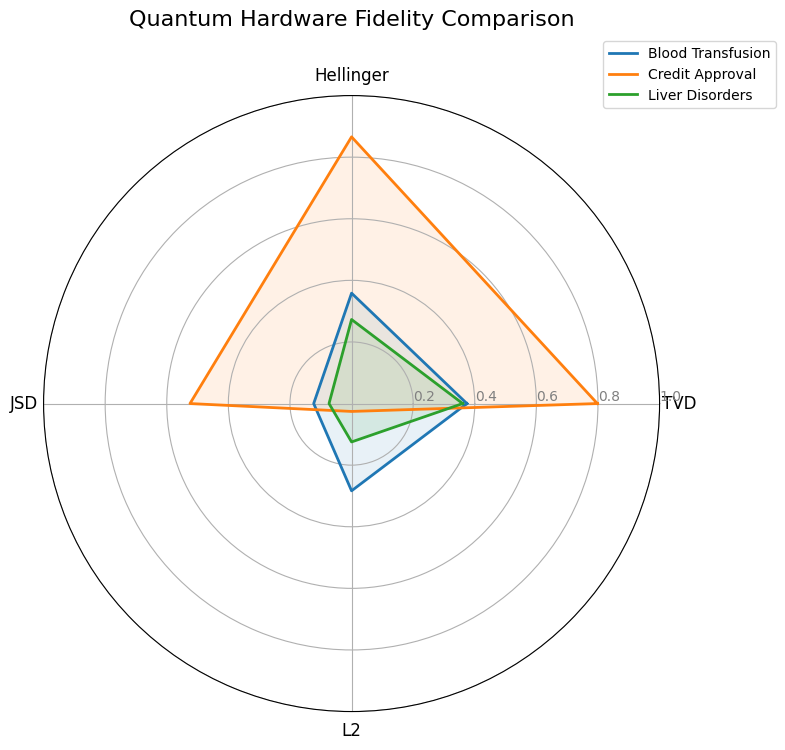

In [7]:
# Radar Chart

import numpy as np
import matplotlib.pyplot as plt

# Data definitions
labels = ['TVD', 'Hellinger', 'JSD', 'L2']
bt_scores = [0.3745, 0.3584, 0.1230, 0.2833]
ca_scores = [0.7981, 0.8659, 0.5246, 0.0256]
ld_scores = [0.3608, 0.2729, 0.0732, 0.1246]

num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Complete the circular loop
bt_scores += bt_scores[:1]
ca_scores += ca_scores[:1]
ld_scores += ld_scores[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], labels, color='black', size=12)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1)

# Plotting
ax.plot(angles, bt_scores, linewidth=2, label='Blood Transfusion')
ax.fill(angles, bt_scores, alpha=0.1)
ax.plot(angles, ca_scores, linewidth=2, label='Credit Approval')
ax.fill(angles, ca_scores, alpha=0.1)
ax.plot(angles, ld_scores, linewidth=2, label='Liver Disorders')
ax.fill(angles, ld_scores, alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.title('Quantum Hardware Fidelity Comparison', size=16, y=1.1)
plt.savefig('radar_chart_drift.png')